In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns

In [3]:
from scipy import sparse
from scipy.stats import entropy, spearmanr, mannwhitneyu, fisher_exact, probplot, kruskal
from scipy.spatial import cKDTree

# H&E image

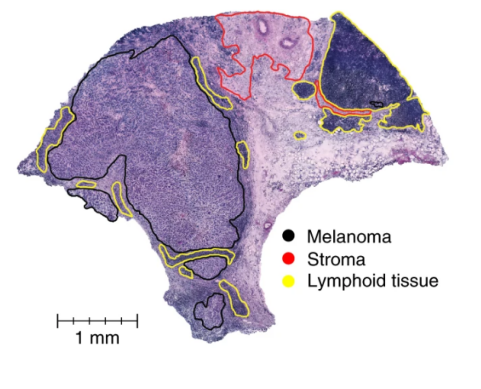

In [4]:
img = mpimg.imread("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/melanoma_rep1.png")

plt.imshow(img)
plt.axis("off")   # hides axes
plt.show()

# Load data ($k=4$)

In [5]:
adata = sc.read_h5ad("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/ST_mel1_rep2.h5ad")
adata.var_names_make_unique()

sc.pp.filter_genes(adata, min_counts=11)

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
adata.layers["norm"] = adata.X.copy()
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

adata

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 293 × 10942
    obs: 'array_row', 'array_col', 'array_col_flipped'
    var: 'gene_id', 'ensemble_id', 'n_counts'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts', 'norm', 'lognorm'

In [6]:
SIGNATURES = {
    "Tumor cells (center)": ["SPP1","HSPB1","ATP1A1","NDRG1","ANXA1"],
    "Tumor cells (border)": ["CXCL10","WARS1","C1QB","GBP4","CXCL9"],
    "Stroma": ["MYL9","CFD","DCN","COL3A1","CH507-513H4.5"],
    "Lymphoid": ["LTB","CD79A","MS4A1","CCL21","CD79B"],
}
marker_genes = [g for ct in SIGNATURES.values() for g in ct if g in adata.var_names]

In [7]:
K=4

## Proportions ($H$)

In [8]:
snmf_proportions = pd.read_csv(f"./K{K}/SNMF_proportions.csv", index_col=0)
snmf_proportions

,V1,V2,V3,V4
7x15,0.273434,0.074859,0.197405,0.454302
7x16,0.214527,0.221338,0.244813,0.319322
7x17,0.113882,0.402638,0.329447,0.154032
7x18,0.105490,0.542102,0.224054,0.128354
8x13,0.096841,0.157761,0.337943,0.407454
...,...,...,...,...
27x18,0.000398,0.508507,0.263692,0.227403
27x19,0.002746,0.511701,0.174788,0.310764
27x20,0.000486,0.306713,0.550300,0.142501
27x21,0.000172,0.046386,0.811832,0.141610


In [9]:
adata.obs = pd.concat([adata.obs, snmf_proportions], axis=1)

## Signatures ($W$)

In [10]:
snmf_signatures = pd.read_csv(f"./K{K}/signatures.csv", index_col=0)
snmf_signatures

,V1,V2,V3,V4
PSME2,2.525697,3.402686,4.120987,15.210362
CUEDC1,0.737316,0.464159,0.175260,0.473928
RPLP1,49.104212,208.518677,89.693282,34.965165
TM9SF3,1.698330,0.774840,1.797161,1.880539
DEF8,1.259931,2.311966,1.620939,1.216029
...,...,...,...,...
MICU3,0.000001,0.330808,0.213525,0.000001
CTAGE5,0.025709,0.181829,0.229819,0.000001
ALPL,0.000001,0.000002,0.411979,0.000001
GPC3,0.000001,0.000002,0.514976,0.000001


In [11]:
adata.var = pd.concat([adata.var, snmf_signatures], axis=1)

## Dispersion parameters ($\phi, \alpha, \beta$)

In [12]:
phi = pd.read_csv(f"./K{K}/phi.csv", index_col=0).T.loc[adata.obs_names, adata.var_names]
alpha = pd.read_csv(f"./K{K}/alpha.csv", index_col=0).T.loc[adata.var_names].values
beta = pd.read_csv(f"./K{K}/beta.csv", index_col=0).T.loc[adata.obs_names].values

adata.var["alpha"] = alpha
adata.obs["beta"] = beta

adata.layers["phi"] = phi
adata.layers["theta"] = 1 / phi

## Spatial filtering matrix $S$

In [13]:
TAU = 0.8

In [14]:
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

positions = np.array(adata.obs_names.str.split("x").tolist()).astype(float)

x = positions[:, 0]
y = positions[:, 1]

def mean_value(gamma, x, y, tau):
    gamma = gamma[0] if np.ndim(gamma) else gamma

    # Pairwise squared Euclidean distances
    coords = np.column_stack((x, y))
    D2 = cdist(coords, coords, metric='sqeuclidean')

    # Similarity matrix
    S = np.exp(-gamma * D2)
    S[S < 1e-3] = 0

    # Row normalization
    row_sums = S.sum(axis=1, keepdims=True)
    S = S / row_sums

    # Objective function
    return (np.mean(np.diag(S)) - tau) ** 2

# Optimize gamma
result = minimize(
    mean_value,
    x0=[1.0],
    args=(x, y, TAU),
    method="BFGS"
)

gamma = result.x[0]

# Compute final normalized similarity matrix
coords = np.column_stack((x, y))
D2 = cdist(coords, coords, metric='sqeuclidean')

S = np.exp(-gamma * D2)
S[S < 1e-3] = 0

row_sums = S.sum(axis=1, keepdims=True)
S = S / row_sums

## Inferred matrix $\hat{V}=WHS$

In [15]:
V = (snmf_signatures.values @ snmf_proportions.values.T @ S).T
adata.X = V

adata.layers["inferred_counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
adata.layers["inferred_norm"] = adata.X.copy()
sc.pp.log1p(adata)
adata.layers["inferred_lognorm"] = adata.X.copy()

# Functions

In [88]:
def valid_genes(genes):
    return [g for g in genes if g in adata.var_names]

def add_expr_score(genes, key, layer=None):
    genes = valid_genes(genes)
    if layer:
        X = adata[:, genes].layers[layer]
    else:
        X = adata[:, genes].X
    vals = X.mean(axis=1)
    adata.obs[key] = vals
    return genes

def add_phi_score(genes, key):
    genes = [g for g in genes if g in phi.columns]
    adata.obs[key] = phi[genes].mean(axis=1)
    return genes

def zscore(s):
    s = pd.Series(s).astype(float)
    sd = s.std()
    return (s - s.mean()) / (sd if sd and not np.isnan(sd) else 1.0)

def compare_by_mask(value_key, mask):
    x = adata.obs.loc[mask, value_key].dropna()
    y = adata.obs.loc[~mask, value_key].dropna()

    if len(x) and len(y):
        res = mannwhitneyu(x, y, alternative="two-sided")
        U = res.statistic
        p = res.pvalue

        # Rank-biserial correlation
        # Positive -> values tend to be higher in x than in y
        r_rb = 2 * U / (len(x) * len(y)) - 1
    else:
        U = np.nan
        p = np.nan
        r_rb = np.nan

    return pd.Series({
        "feature": value_key,
        "in_median": x.median(),
        "out_median": y.median(),
        "U": U,
        "p": p,
        "effect_size_r": r_rb,
        "n_in": len(x),
        "n_other": len(y),
    })

# Annotation

In [17]:
import numpy as np

snmf_z = (snmf_signatures - snmf_signatures.mean(axis=0)) / snmf_signatures.std(axis=0)

score_table = pd.DataFrame(index=SIGNATURES.keys(),
                           columns=snmf_z.columns,
                           dtype=float)

for comp in snmf_z.columns:
    for celltype, markers in SIGNATURES.items():
        valid = [g for g in markers if g in snmf_z.index]
        if len(valid) > 0:
            score_table.loc[celltype, comp] = (
                snmf_z.loc[valid, comp].mean() - snmf_z[comp].mean()
            )
        else:
            score_table.loc[celltype, comp] = -np.inf

# --------------------------------------------------
# 2️⃣ Annotation function
# --------------------------------------------------
def unique_assignment(score_table, threshold=0.2):
    
    # For each component, sort cell types by descending score
    ranked = {
        comp: score_table[comp].sort_values(ascending=False).index.tolist()
        for comp in score_table.columns
    }
    
    assigned_celltypes = set()
    final_assignment = {}
    
    # Sort components by their BEST score (descending)
    components_order = sorted(
        score_table.columns,
        key=lambda c: score_table[c].max(),
        reverse=True
    )
    
    for comp in components_order:
        for celltype in ranked[comp]:
            
            if score_table.loc[celltype, comp] < threshold:
                final_assignment[comp] = "ambiguous"
                break
            
            if celltype not in assigned_celltypes:
                final_assignment[comp] = celltype
                assigned_celltypes.add(celltype)
                break
        else:
            final_assignment[comp] = "ambiguous"
    
    return pd.Series(final_assignment)

# --------------------------------------------------
# 3️⃣ Apply to all components
# --------------------------------------------------
annotation = unique_assignment(score_table)

print(annotation)

V1    Tumor cells (center)
V2                  Stroma
V4    Tumor cells (border)
V3                Lymphoid
dtype: object


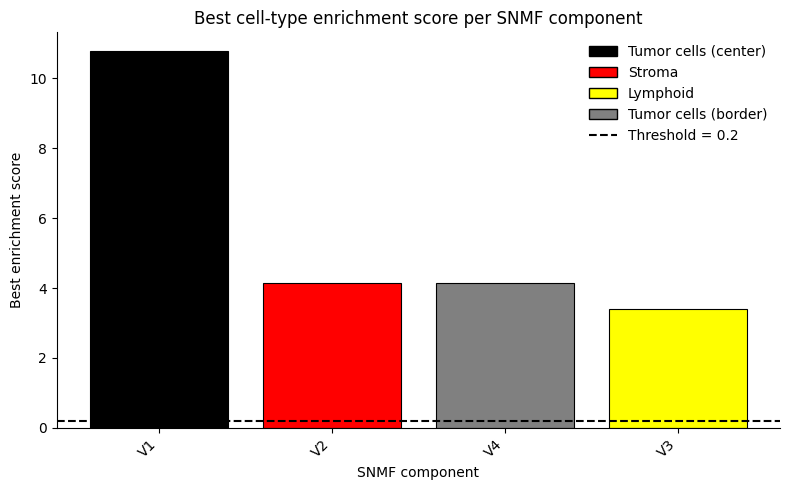

In [18]:
PALETTE = {
    "Tumor cells (center)": "black",
    "Stroma": "red",
    "Lymphoid": "yellow",
    "Tumor cells (border)": "gray",
    "ambiguous": "lightgray",   # optional
}

threshold = 0.2

# Best enrichment score for each component
best_scores = score_table.max(axis=0)

# Sort by score
best_scores = best_scores.sort_values(ascending=False)

# Match annotations to sorted components
annotation_sorted = annotation.loc[best_scores.index]

# Colors according to assigned cell type
colors = [PALETTE.get(ct, "lightgray") for ct in annotation_sorted]

fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(best_scores)), 5))

x = np.arange(len(best_scores))

ax.bar(
    x,
    best_scores.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.axhline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold = {threshold}"
)

ax.set_xticks(x)
ax.set_xticklabels(best_scores.index, rotation=45, ha="right")
ax.set_xlabel("SNMF component")
ax.set_ylabel("Best enrichment score")
ax.set_title("Best cell-type enrichment score per SNMF component")

# Legend for cell types
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=color, edgecolor="black", label=celltype)
    for celltype, color in PALETTE.items()
    if celltype != "ambiguous"
]
legend_handles.append(
    plt.Line2D([0], [0], color="black", linestyle="--",
               label=f"Threshold = {threshold}")
)

ax.legend(handles=legend_handles, frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig(
    f"plots/K{K}_snmf_component_enrichment.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    f"plots/K{K}_snmf_component_enrichment.pdf",
    bbox_inches="tight"
)

plt.show()

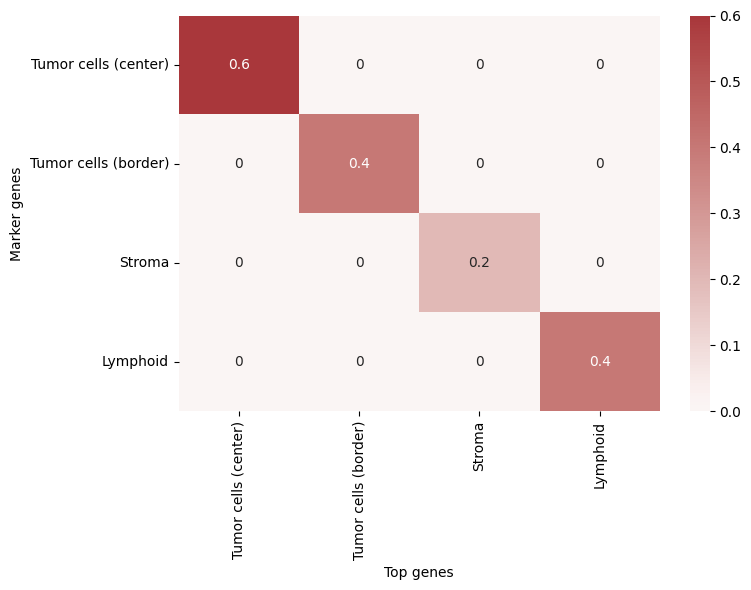

In [19]:
def gini_coefficient(values):
    """
    Compute the Gini coefficient of a one-dimensional non-negative array.

    Returns:
        0: equal loading across all components
        1: loading concentrated in one component
    """
    values = np.asarray(values, dtype=float)

    if np.any(values < 0):
        raise ValueError("Gini coefficient requires non-negative values.")

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)

    return (
        2 * np.sum((np.arange(1, n + 1)) * values)
        / (n * values.sum())
        - (n + 1) / n
    )

# Gini specificity of each gene across all NMF components
gene_gini = snmf_signatures.apply(gini_coefficient, axis=1)

# Component with the highest loading for each gene
gene_component = snmf_signatures.idxmax(axis=1)

szymkiewicz_simpson = np.zeros((len(SIGNATURES), len(SIGNATURES))) # Szymkiewicz–Simpson coefficient

reverse_annotation = {v: k for k, v in annotation.items()}

for i, ct1 in enumerate(SIGNATURES):
    ct_marker_genes = set(SIGNATURES[ct1])

    for j, ct2 in enumerate(SIGNATURES):
        k = reverse_annotation.get(ct2)

        if k is None:
            raise KeyError(f"No NMF component found for cell type: {ct2}")

        assigned_to_k = gene_component == k

        score = (
            gene_gini[assigned_to_k]
            * snmf_signatures.loc[assigned_to_k, k]
        )

        top_genes = set(
            score.sort_values(ascending=False)
            .head(20)
            .index
        )

        szymkiewicz_simpson[i, j] = (
            len(ct_marker_genes & top_genes) / min(len(ct_marker_genes), len(top_genes))
        )

szymkiewicz_simpson = pd.DataFrame(
    szymkiewicz_simpson,
    index=SIGNATURES.keys(),
    columns=SIGNATURES.keys(),
)

plt.figure(figsize=(8, 6))
sns.heatmap(szymkiewicz_simpson, annot=True, cmap="vlag", center=0)
plt.title("")
plt.xlabel("Top genes")
plt.ylabel("Marker genes")

plt.tight_layout()

plt.savefig(f"plots/K{K}_marker_top_genes_overlap.png", dpi=300)
plt.savefig(f"plots/K{K}_marker_top_genes_overlap.pdf", dpi=300)
plt.show()

In [20]:
N_TOP_GENES = 5

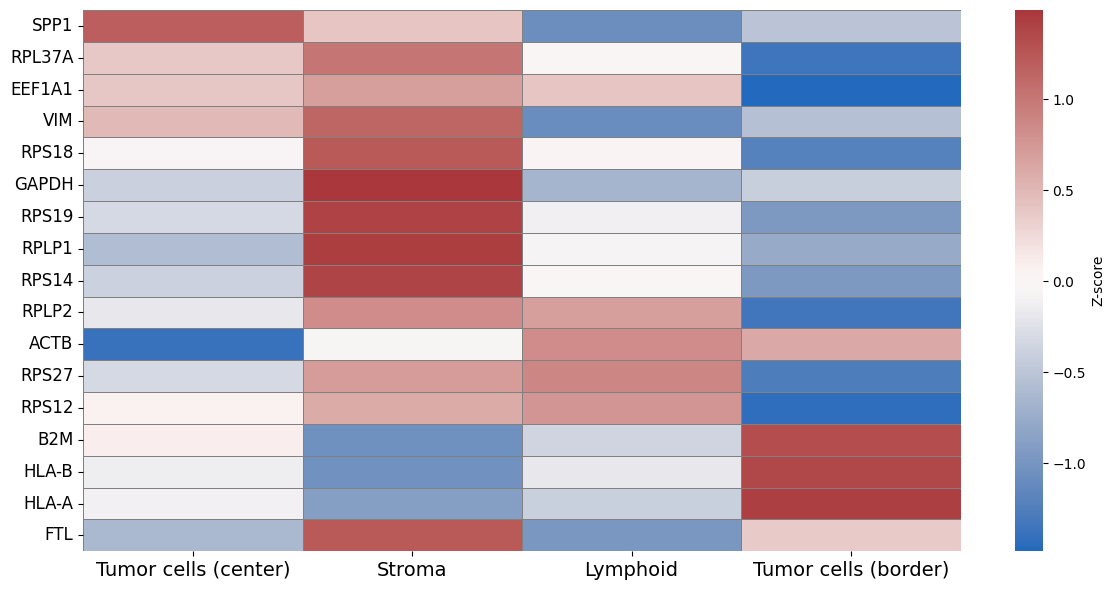

In [21]:
top_genes_ordered = []
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    top_genes_ordered.extend([g for g in top_genes if g not in top_genes_ordered])

# Subset and reorder genes
snmf_top = snmf_signatures.loc[top_genes_ordered]

# ----- 2️⃣ Scale genes (row-wise z-score) -----
snmf_scaled = snmf_top.sub(snmf_top.mean(axis=1), axis=0).div(snmf_top.std(axis=1), axis=0)

# ----- 3️⃣ Fancy heatmap with Seaborn -----
plt.figure(figsize=(12, max(6, len(top_genes_ordered) * 0.25)))

# sns.set_style("white")
# sns.set_context("talk")

# Optionally, order components by annotation or clustering
sns.heatmap(
    snmf_scaled,
    cmap="vlag",          # diverging colormap for z-scores
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Z-score"},
    xticklabels=[annotation.get(c, c) for c in snmf_scaled.columns],
    yticklabels=snmf_scaled.index
)

plt.xticks(fontsize=14)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(f"plots/K{K}_top_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_top_genes_heatmap.pdf", dpi=300)
plt.show()

In [22]:
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    print(f"{annotation[comp]} variance: {snmf_scaled.loc[top_genes,comp].var()}")
    print(f"{annotation[comp]} range: {snmf_scaled.loc[top_genes,comp].max() - snmf_scaled.loc[top_genes,comp].min()}")
    print(f"{annotation[comp]} mean: {snmf_scaled.loc[top_genes,comp].mean()}")
    print()

Tumor cells (center) variance: 0.19959900459439317
Tumor cells (center) range: 1.2367056417202629
Tumor cells (center) mean: 0.48116135074842586

Stroma variance: 0.009766460911734887
Stroma range: 0.2642799928223738
Stroma mean: 1.3877878105503563

Lymphoid variance: 0.03582384899103049
Lymphoid range: 0.47849786276146833
Lymphoid mean: 0.7150376246601223

Tumor cells (border) variance: 0.24064371424882774
Tumor cells (border) range: 1.0520197052073708
Tumor cells (border) mean: 1.0183456585420427



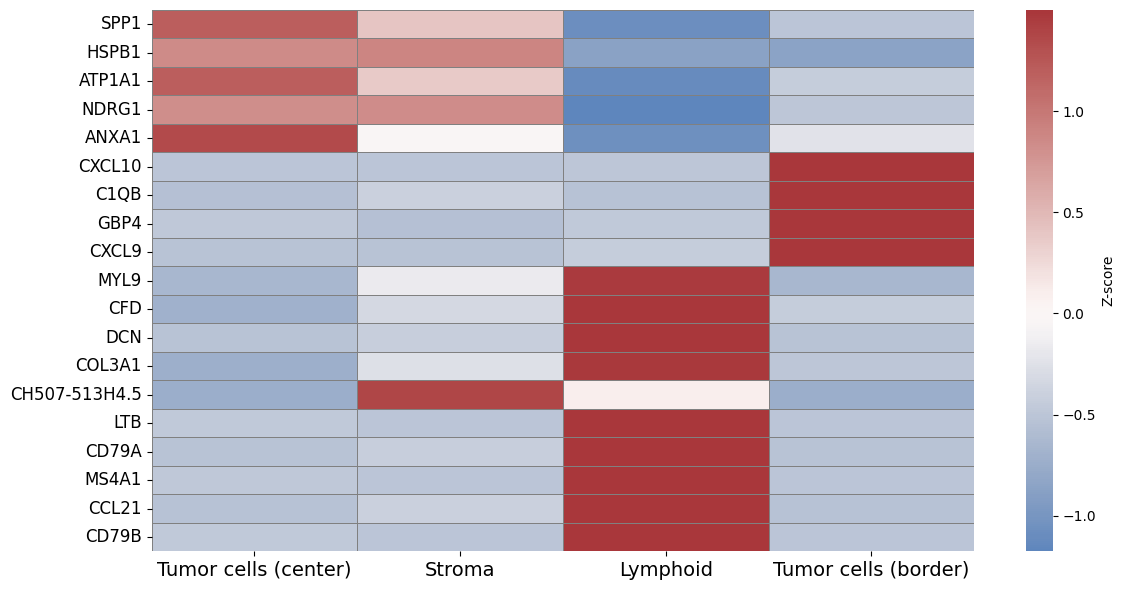

In [23]:
# Subset and reorder genes
snmf_mgs = snmf_signatures.loc[marker_genes]

# ----- 2️⃣ Scale genes (row-wise z-score) -----
snmf_scaled = snmf_mgs.sub(snmf_mgs.mean(axis=1), axis=0).div(snmf_mgs.std(axis=1), axis=0)

# ----- 3️⃣ Fancy heatmap with Seaborn -----
plt.figure(figsize=(12, max(6, len(marker_genes) * 0.25)))

# sns.set_style("white")
# sns.set_context("talk")

# Optionally, order components by annotation or clustering
sns.heatmap(
    snmf_scaled,
    cmap="vlag",          # diverging colormap for z-scores
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Z-score"},
    xticklabels=[annotation.get(c, c) for c in snmf_scaled.columns],
    yticklabels=snmf_scaled.index
)

plt.xticks(fontsize=14)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(f"plots/K{K}_marker_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_marker_genes_heatmap.pdf", dpi=300)
plt.show()

In [24]:
adata.obs.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.obs.columns]
adata.var.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.var.columns]

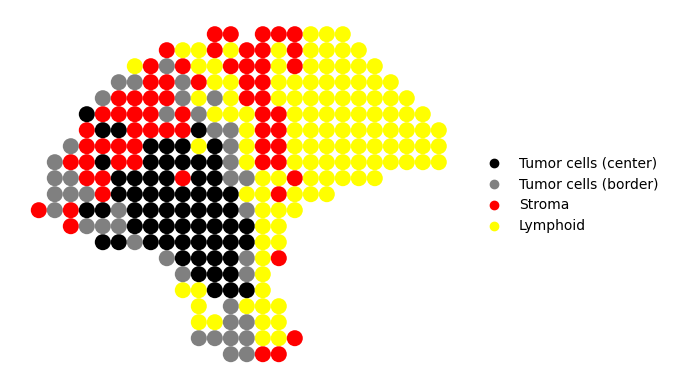

In [25]:
adata.obs["snmf_component"] = adata.obs[[annotation[c] for c in snmf_signatures.columns]].idxmax(axis=1)
adata.obs["snmf_component"] = pd.Categorical(
    adata.obs["snmf_component"],
    categories=list(SIGNATURES.keys()),  # keep ambiguous if it exists
    ordered=True,
)

PALETTE = {
    "Tumor cells (center)": "black",
    "Stroma": "red",
    "Lymphoid": "yellow",
    "Tumor cells (border)": "gray",
}

sc.pl.spatial(
    adata,
    color="snmf_component",
    palette=PALETTE,
    spot_size=1,
    frameon=False,
    title="",
    show=False,
)

plt.savefig(f"plots/K{K}_clustering.png", dpi=300)
plt.savefig(f"plots/K{K}_clustering.pdf", dpi=300)
plt.show()

<Figure size 1400x600 with 0 Axes>

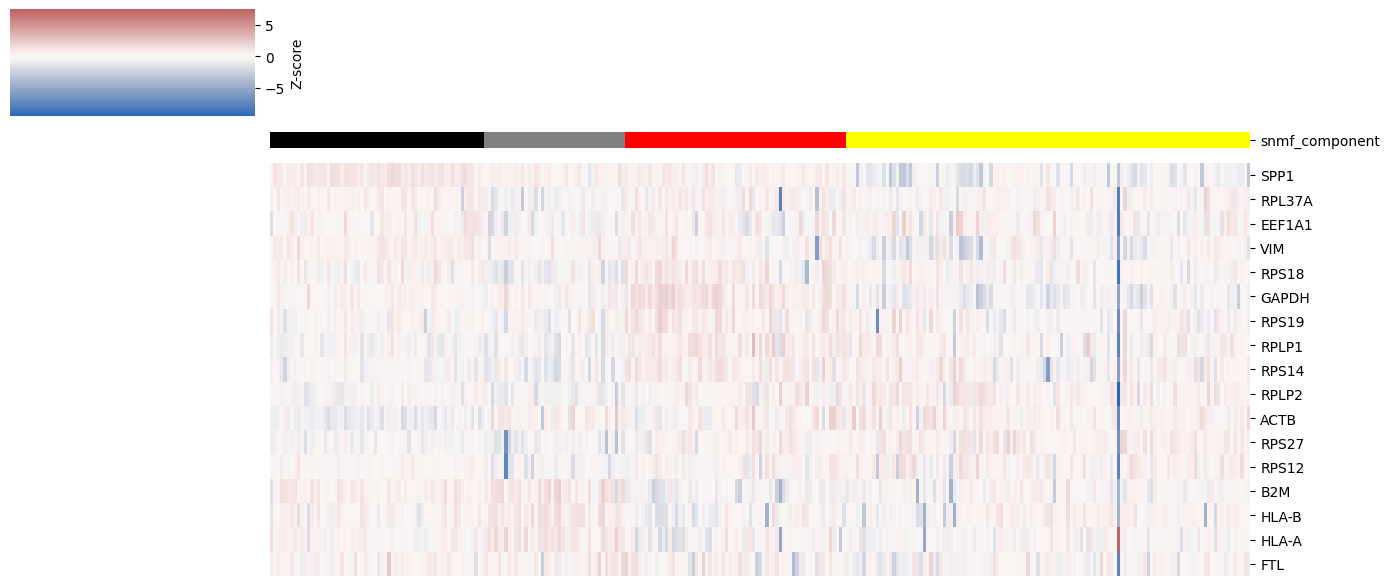

In [26]:
expr = pd.DataFrame(
    adata[:, top_genes_ordered].layers["lognorm"].toarray(),
    index=adata.obs_names,
    columns=top_genes_ordered
).T

spot_order = adata.obs[adata.obs["snmf_component"] != "ambiguous"].sort_values("snmf_component").index
expr = expr[spot_order]

expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1), axis=0)

cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))

col_colors = adata.obs["snmf_component"].map(lut)

plt.figure(figsize=(14, max(6, len(top_genes_ordered)*0.25)))

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(top_genes_ordered)*0.25)),
    cbar_kws={"label": "Z-score"}
)

plt.tight_layout()

plt.savefig(f"plots/K{K}_V_expression_top_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_V_expression_top_genes_heatmap.pdf", dpi=300)
plt.show()

<Figure size 1400x600 with 0 Axes>

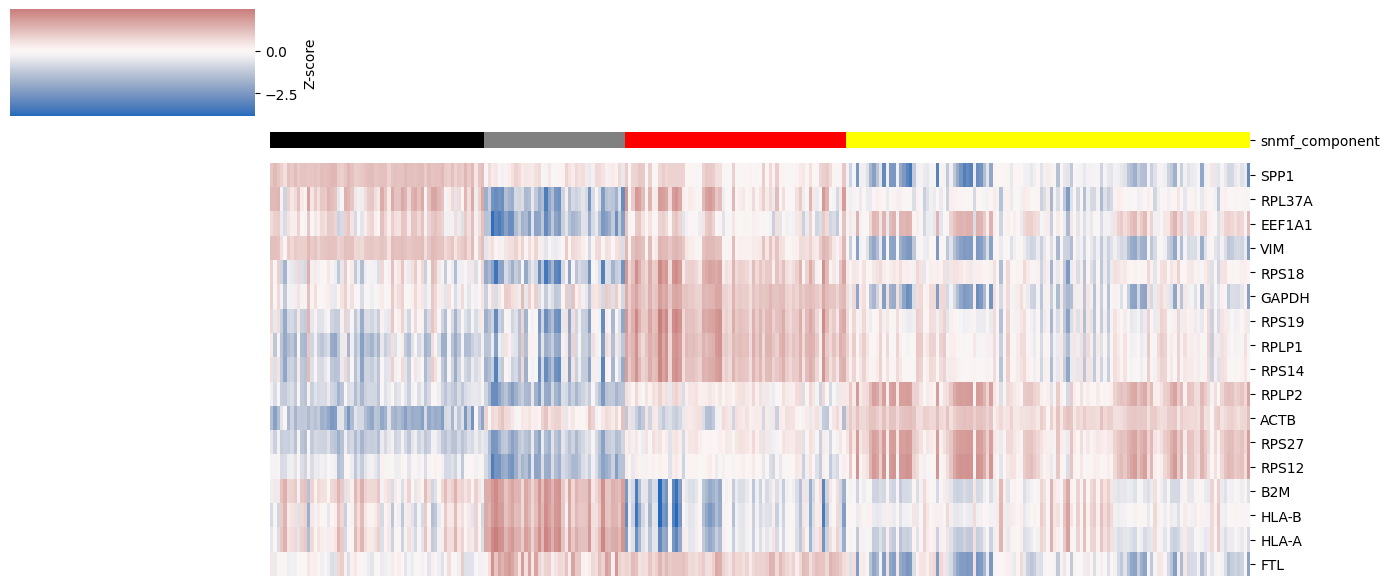

In [27]:
expr = pd.DataFrame(
    adata[:, top_genes_ordered].layers["inferred_lognorm"].toarray(),
    index=adata.obs_names,
    columns=top_genes_ordered
).T

spot_order = adata.obs[adata.obs["snmf_component"] != "ambiguous"].sort_values("snmf_component").index
expr = expr[spot_order]

expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1), axis=0)

cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))

col_colors = adata.obs["snmf_component"].map(lut)

plt.figure(figsize=(14, max(6, len(top_genes_ordered)*0.25)))

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(top_genes_ordered)*0.25)),
    cbar_kws={"label": "Z-score"}
)

plt.tight_layout()

plt.savefig(f"plots/K{K}_WHS_expression_top_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_WHS_expression_top_genes_heatmap.pdf", dpi=300)
plt.show()

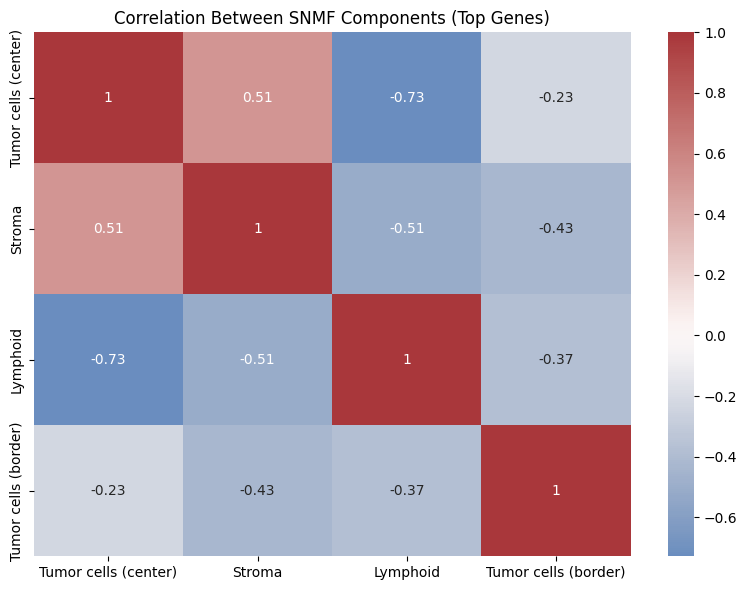

In [28]:
corr_matrix = snmf_scaled.corr()
labels = [annotation.get(c, c) for c in snmf_scaled.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="vlag", center=0)
plt.title("Correlation Between SNMF Components (Top Genes)")

plt.tight_layout()

plt.savefig(f"plots/K{K}_top_genes_corr.png", dpi=300)
plt.savefig(f"plots/K{K}_top_genes_corr.pdf", dpi=300)
plt.show()

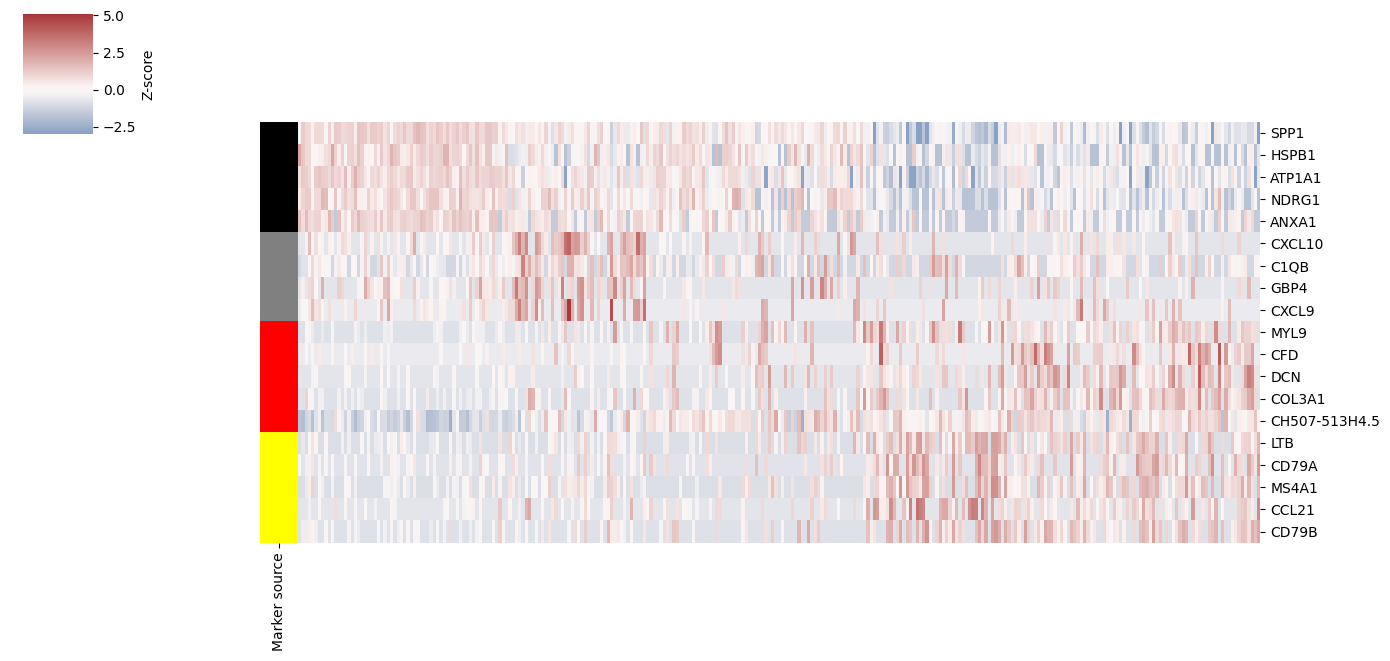

In [29]:
import matplotlib

gene_to_celltype = {
    gene: cell_type
    for cell_type, genes in SIGNATURES.items()
    for gene in genes
    if gene in marker_genes
}

expr = pd.DataFrame(
    adata[:, marker_genes].layers["lognorm"].toarray(),
    index=adata.obs_names,
    columns=marker_genes,
).T

spot_order = (
    adata.obs.loc[adata.obs["snmf_component"] != "ambiguous"]
    .sort_values("snmf_component")
    .index
)

expr = expr.loc[:, spot_order]

# Z-score each gene
expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(
    expr.std(axis=1).replace(0, np.nan),
    axis=0,
)

# Column annotation: sNMF component
cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]
lut = dict(zip(cats, colors))

row_colors = pd.Series(
    [lut.get(gene_to_celltype[g], "lightgrey") for g in expr_scaled.index],
    index=expr_scaled.index,
    name="Marker source",
)

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(marker_genes) * 0.35)),
    cbar_kws={"label": "Z-score"},
)

g.savefig(
    f"plots/K{K}_V_expression_marker_genes_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

g.savefig(
    f"plots/K{K}_V_expression_marker_genes_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

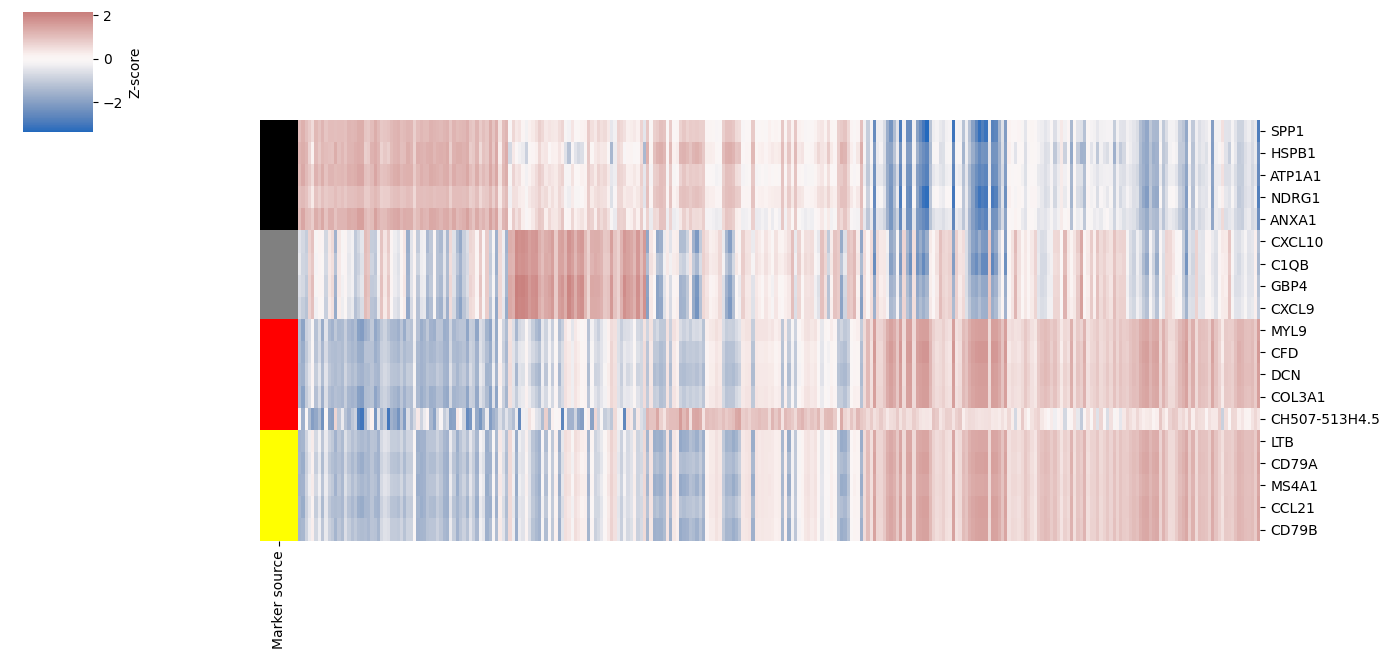

In [30]:
gene_to_celltype = {
    gene: cell_type
    for cell_type, genes in SIGNATURES.items()
    for gene in genes
    if gene in marker_genes
}

expr = pd.DataFrame(
    adata[:, marker_genes].layers["inferred_lognorm"].toarray(),
    index=adata.obs_names,
    columns=marker_genes,
).T

spot_order = (
    adata.obs.loc[adata.obs["snmf_component"] != "ambiguous"]
    .sort_values("snmf_component")
    .index
)

expr = expr.loc[:, spot_order]

# Z-score each gene
expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(
    expr.std(axis=1).replace(0, np.nan),
    axis=0,
)

# Column annotation: sNMF component
cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]
lut = dict(zip(cats, colors))

row_colors = pd.Series(
    [lut.get(gene_to_celltype[g], "lightgrey") for g in expr_scaled.index],
    index=expr_scaled.index,
    name="Marker source",
)

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(marker_genes) * 0.35)),
    cbar_kws={"label": "Z-score"},
)

g.savefig(
    f"plots/K{K}_WHS_expression_marker_genes_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

g.savefig(
    f"plots/K{K}_WHS_expression_marker_genes_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

# Proportions

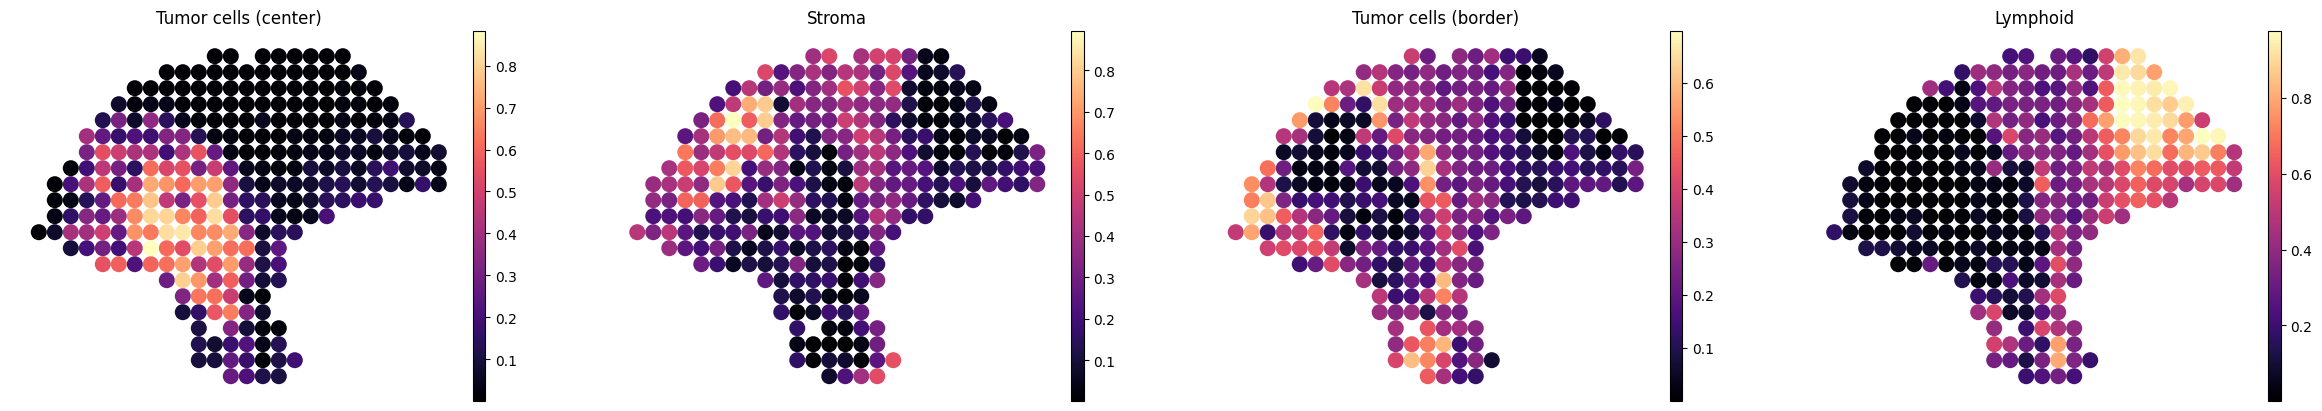

/tmp/ipykernel_846876/4088176622.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [31]:
colors = annotation.unique().tolist()

fig = sc.pl.spatial(
    adata,
    color=colors,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(colors),
    return_fig=True,
    show=True
)

# Adjust spacing (important when many panels)
fig.tight_layout()

# Save in both formats
fig.savefig(f"plots/K{K}_proportions.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_proportions.pdf", dpi=300, bbox_inches="tight")

plt.close(fig)

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-08 12:37:08.173819: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-08 12:37:09.857932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-08 12:37:53.463514: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see sli

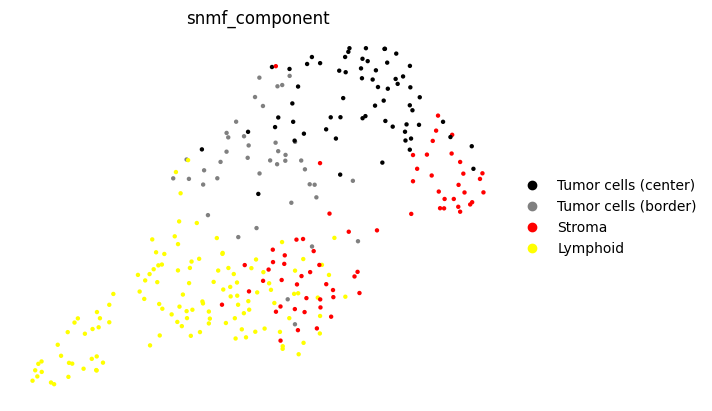

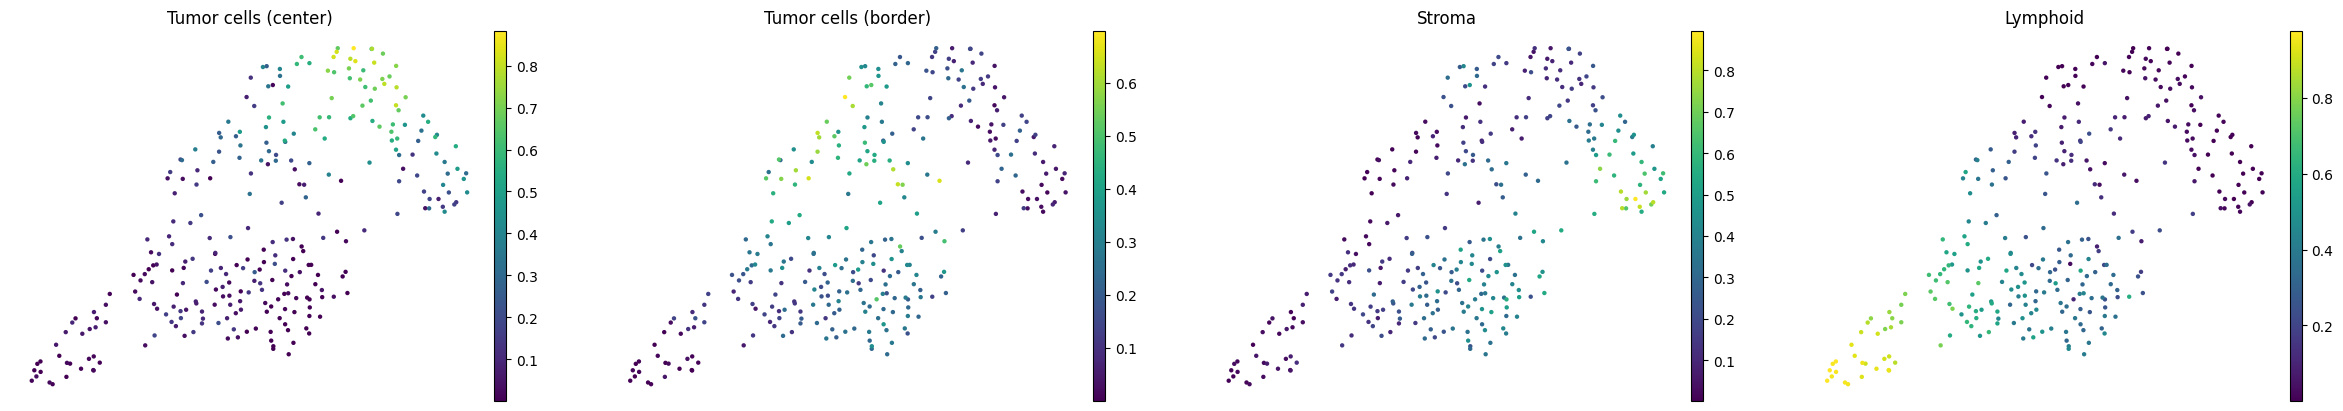

In [32]:
sc.pp.pca(
    adata,
    n_comps=30,
    svd_solver="arpack",
    layer="lognorm"
)

sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30,
)

sc.tl.umap(adata)

fig = sc.pl.umap(
    adata,
    color=["snmf_component"],
    size=40,
    frameon=False,
    return_fig=True,
)

fig.savefig(f"plots/K{K}_V_umap_clustering.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_V_umap_clustering.pdf", dpi=300, bbox_inches="tight")
plt.show()

fig = sc.pl.umap(
    adata,
    color=list(SIGNATURES.keys()),
    size=40,
    ncols=4,
    frameon=False,
    return_fig=True,
)

fig.savefig(f"plots/K{K}_V_umap_proportions.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_V_umap_proportions.pdf", dpi=300, bbox_inches="tight")
plt.show()

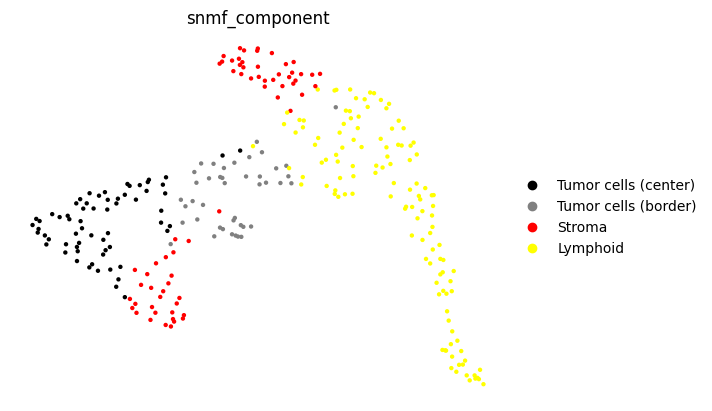

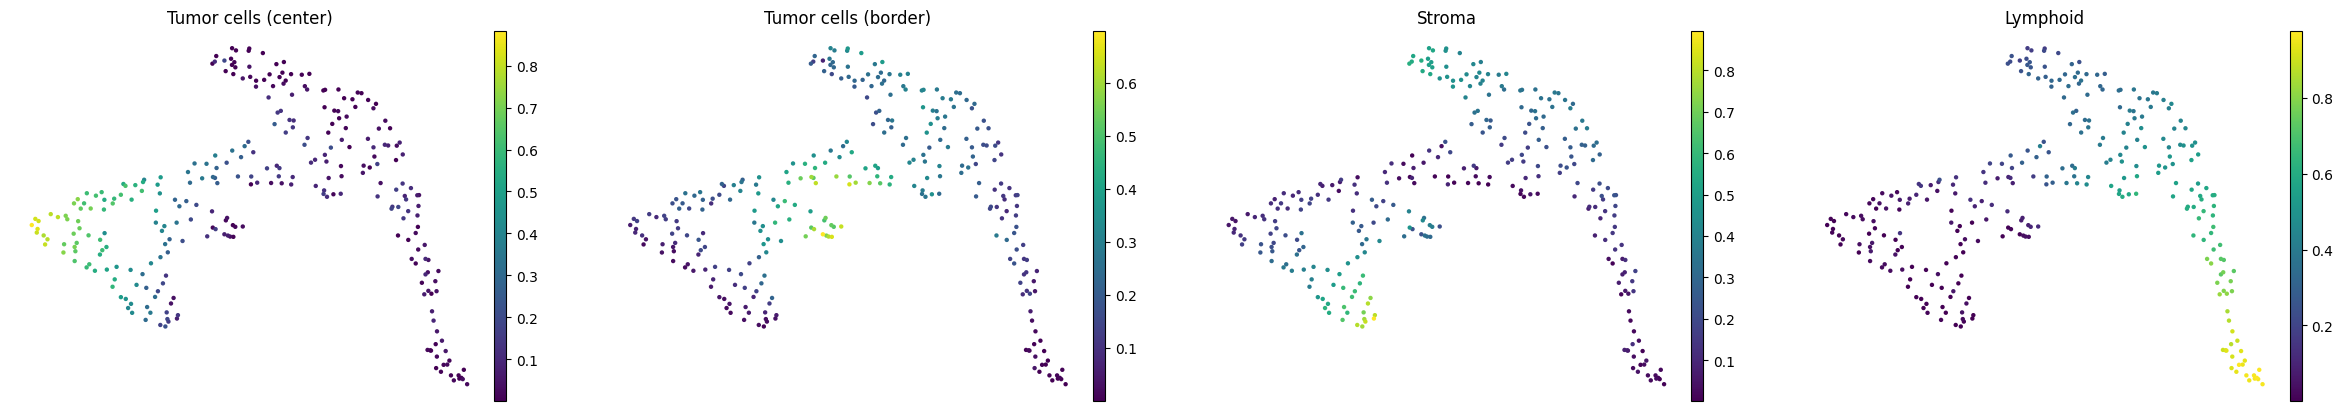

In [33]:
sc.pp.pca(
    adata,
    n_comps=30,
    svd_solver="arpack",
)

sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30,
)

sc.tl.umap(adata)

fig = sc.pl.umap(
    adata,
    color=["snmf_component"],
    size=40,
    frameon=False,
    return_fig=True,
)

fig.savefig(f"plots/K{K}_WHS_umap_clustering.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_WHS_umap_clustering.pdf", dpi=300, bbox_inches="tight")
plt.show()

fig = sc.pl.umap(
    adata,
    color=list(SIGNATURES.keys()),
    size=40,
    ncols=4,
    frameon=False,
    return_fig=True,
)

fig.savefig(f"plots/K{K}_WHS_umap_proportions.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_WHS_umap_proportions.pdf", dpi=300, bbox_inches="tight")
plt.show()

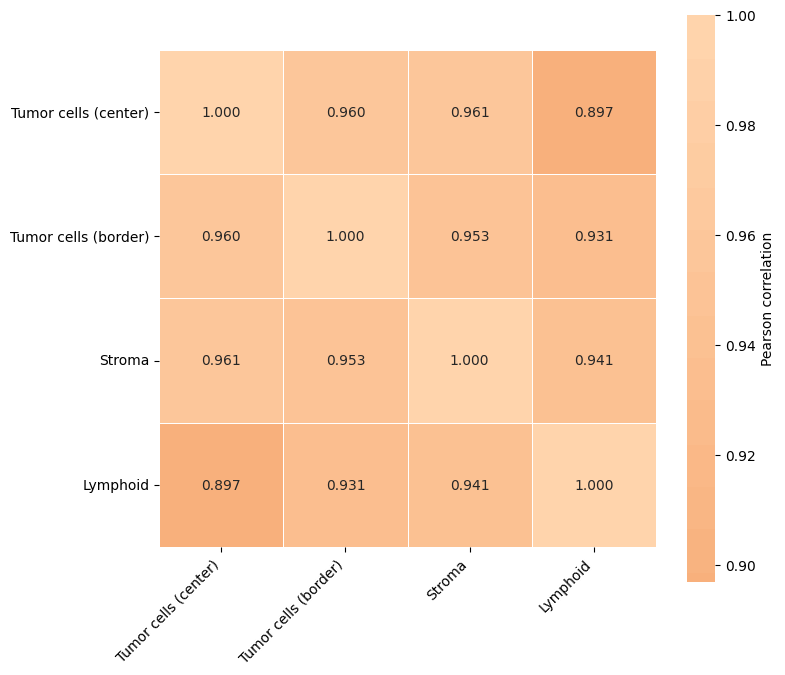

In [34]:
from scipy.stats import pearsonr

X = adata.layers["lognorm"]

if sparse.issparse(X):
    X = X.toarray()

celltypes = list(SIGNATURES.keys())

means = {}
for ct in celltypes:
    means[ct] = X[adata.obs["snmf_component"] == ct].mean(axis=0)

corr = pd.DataFrame(index=celltypes, columns=celltypes, dtype=float)

for ct1 in celltypes:
    for ct2 in celltypes:
        r, _ = pearsonr(means[ct1], means[ct2])
        corr.loc[ct1, ct2] = r

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    # cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Spatial autocorrelation for each cell type

In [35]:
import squidpy as sq

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [36]:
sq.gr.spatial_neighbors(
    adata,
    spatial_key="spatial",
    coord_type="generic"
)

# compute Moran's I for every cell-type proportion
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    genes=SIGNATURES.keys(),
    attr="obs",
    n_perms=1000
)

# results
moran_df = adata.uns["moranI"].copy()
moran_df = moran_df.sort_values("I", ascending=False)

print(moran_df)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2032.74/s]


                             I  pval_norm  var_norm  pval_z_sim  pval_sim  \
Lymphoid              0.861518        0.0  0.001012         0.0  0.000999   
Tumor cells (center)  0.786226        0.0  0.001012         0.0  0.000999   
Stroma                0.663883        0.0  0.001012         0.0  0.000999   
Tumor cells (border)  0.557482        0.0  0.001012         0.0  0.000999   

                       var_sim  pval_norm_fdr_bh  pval_z_sim_fdr_bh  \
Lymphoid              0.003245               0.0                0.0   
Tumor cells (center)  0.002612               0.0                0.0   
Stroma                0.002253               0.0                0.0   
Tumor cells (border)  0.001826               0.0                0.0   

                      pval_sim_fdr_bh  
Lymphoid                     0.000999  
Tumor cells (center)         0.000999  
Stroma                       0.000999  
Tumor cells (border)         0.000999  


/tmp/ipykernel_846876/1592364696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


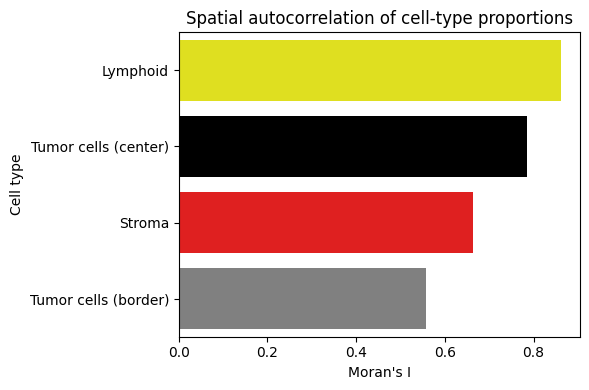

In [37]:
plt.figure(figsize=(6, max(4, 0.3 * len(moran_df))))
sns.barplot(
    data=moran_df.reset_index(),
    y="index",
    x="I",
    palette=PALETTE
)
plt.xlabel("Moran's I")
plt.ylabel("Cell type")
plt.title("Spatial autocorrelation of cell-type proportions")
plt.tight_layout()

plt.savefig(f"plots/K{K}_cell_type_morans_i.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_cell_type_morans_i.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Dispersion analysis with additive factors $\alpha$ and $\beta$

## $\alpha_i$

/tmp/ipykernel_846876/3555865285.py:7: RuntimeWarning: invalid value encountered in log1p
  sns.histplot(np.log1p(alpha), bins=50, kde=True, ax=axes[1])


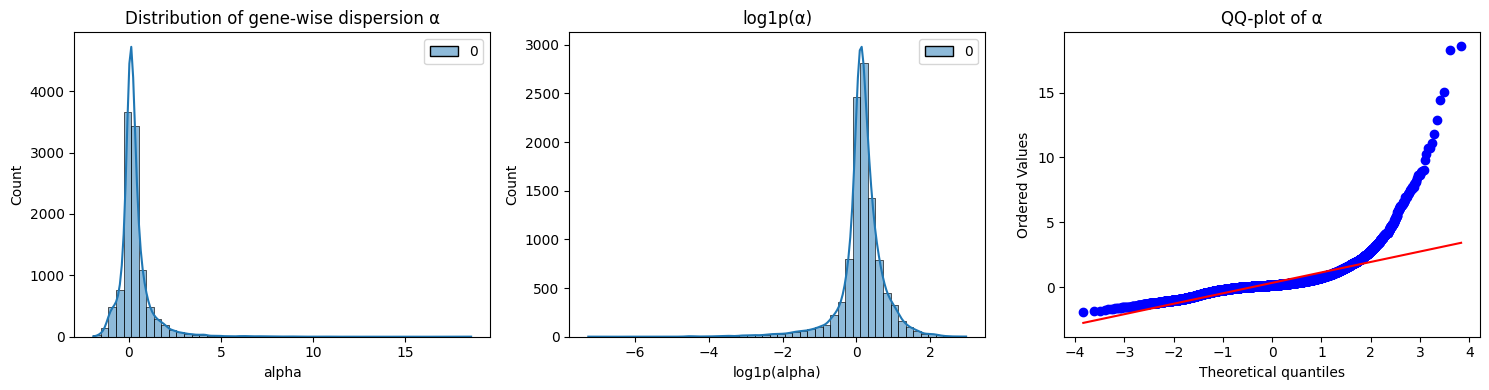

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(alpha, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of gene-wise dispersion α")
axes[0].set_xlabel("alpha")

sns.histplot(np.log1p(alpha), bins=50, kde=True, ax=axes[1])
axes[1].set_title("log1p(α)")
axes[1].set_xlabel("log1p(alpha)")

probplot(alpha.ravel(), dist="norm", plot=axes[2])
axes[2].set_title("QQ-plot of α")

plt.tight_layout()

plt.savefig(f"plots/K{K}_alpha_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_alpha_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
top_alpha_genes = (
    adata.var[["alpha"]]
    .sort_values("alpha", ascending=False)
)

top_alpha_genes.head(50).index.tolist()

['NAT6',
 'XRRA1',
 'PVT1',
 'ZNF407',
 'RP11-394O4.5',
 'CYB5D1',
 'CHI3L1',
 'AP001258.4',
 'TBC1D3C',
 'FLT4',
 'TPSB2',
 'CTAGE5',
 'CCDC78',
 'RP11-539L10.3',
 'CASZ1',
 'TPPP3',
 'VMAC',
 'PTGIS',
 'ITK',
 'TREM2',
 'NAIP',
 'CEACAM21',
 'C18orf54',
 'KLHDC1',
 'LINC01588',
 'SNCG',
 'CCL8',
 'DES',
 'DNM1',
 'SPEG',
 'NFAM1',
 'DNALI1',
 'VGLL4',
 'NINL',
 'MAP3K5',
 'LIPE',
 'SSH3',
 'IRX6',
 'SPIN4',
 'COL5A3',
 'RHOBTB1',
 'CCBL2',
 'RRAGB',
 'C20orf96',
 'MON1A',
 'ZC3H8',
 'UVSSA',
 'CHIT1',
 'C3AR1',
 'LAMB3']

### Mean expression vs $\alpha$

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


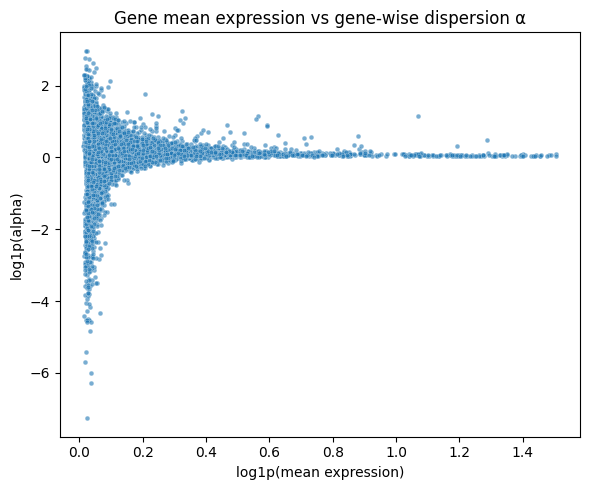

In [40]:
X = adata.layers["lognorm"]

if sparse.issparse(X):
    gene_mean = np.asarray(X.mean(axis=0)).ravel()
else:
    gene_mean = X.mean(axis=0)

adata.var["mean_expression"] = gene_mean
adata.var["log1p_mean_expression"] = np.log1p(gene_mean)
adata.var["log1p_alpha"] = np.log1p(adata.var["alpha"])

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=adata.var,
    x="log1p_mean_expression",
    y="log1p_alpha",
    s=12,
    alpha=0.6
)
plt.xlabel("log1p(mean expression)")
plt.ylabel("log1p(alpha)")
plt.title("Gene mean expression vs gene-wise dispersion α")
plt.tight_layout()

plt.savefig(f"plots/K{K}_alpha_vs_mean_exp.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_alpha_vs_mean_exp.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
rho, pval = spearmanr(
    adata.var["mean_expression"],
    adata.var["alpha"],
    nan_policy="omit"
)

print(f"Spearman correlation mean expression vs alpha: rho={rho:.3f}, p={pval:.3e}")

Spearman correlation mean expression vs alpha: rho=-0.054, p=1.176e-08


**$\alpha$ does not merely track abundance**

### HVGs vs $\alpha$

In [42]:
N = 2000

In [43]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=N
)

adata.var["low_alpha"] = False
low_alpha_genes = top_alpha_genes.tail(N).index
adata.var.loc[low_alpha_genes, "low_alpha"] = True

hvg = set(adata.var_names[adata.var["highly_variable"]])
low_alpha = set(low_alpha_genes)

overlap = len(hvg & low_alpha)

print(f"HVG genes: {len(hvg)}")
print(f"High-alpha genes: {len(low_alpha)}")
print(f"Overlap: {overlap}")
print(f"Jaccard index: {overlap / len(hvg | low_alpha):.3f}")

HVG genes: 2000
High-alpha genes: 2000
Overlap: 246
Jaccard index: 0.066


In [44]:
contingency = pd.crosstab(
    adata.var["highly_variable"],
    adata.var["low_alpha"]
)

contingency

low_alpha,False,True
highly_variable,,
False,7188,1754
True,1754,246


For a 2x2 table, the null hypothesis is that the true odds ratio of the populations underlying the observations is one, and the observations were sampled from these populations under a condition: the marginals of the resulting table must equal those of the observed table. The statistic is the unconditional maximum likelihood estimate of the odds ratio

In [45]:
oddsratio, pval = fisher_exact(contingency)
print(f"Fisher exact test: odds ratio={oddsratio:.3f}, p={pval:.3e}")

Fisher exact test: odds ratio=0.575, p=2.177e-15


### Spatial maps of genes with higher $\alpha$

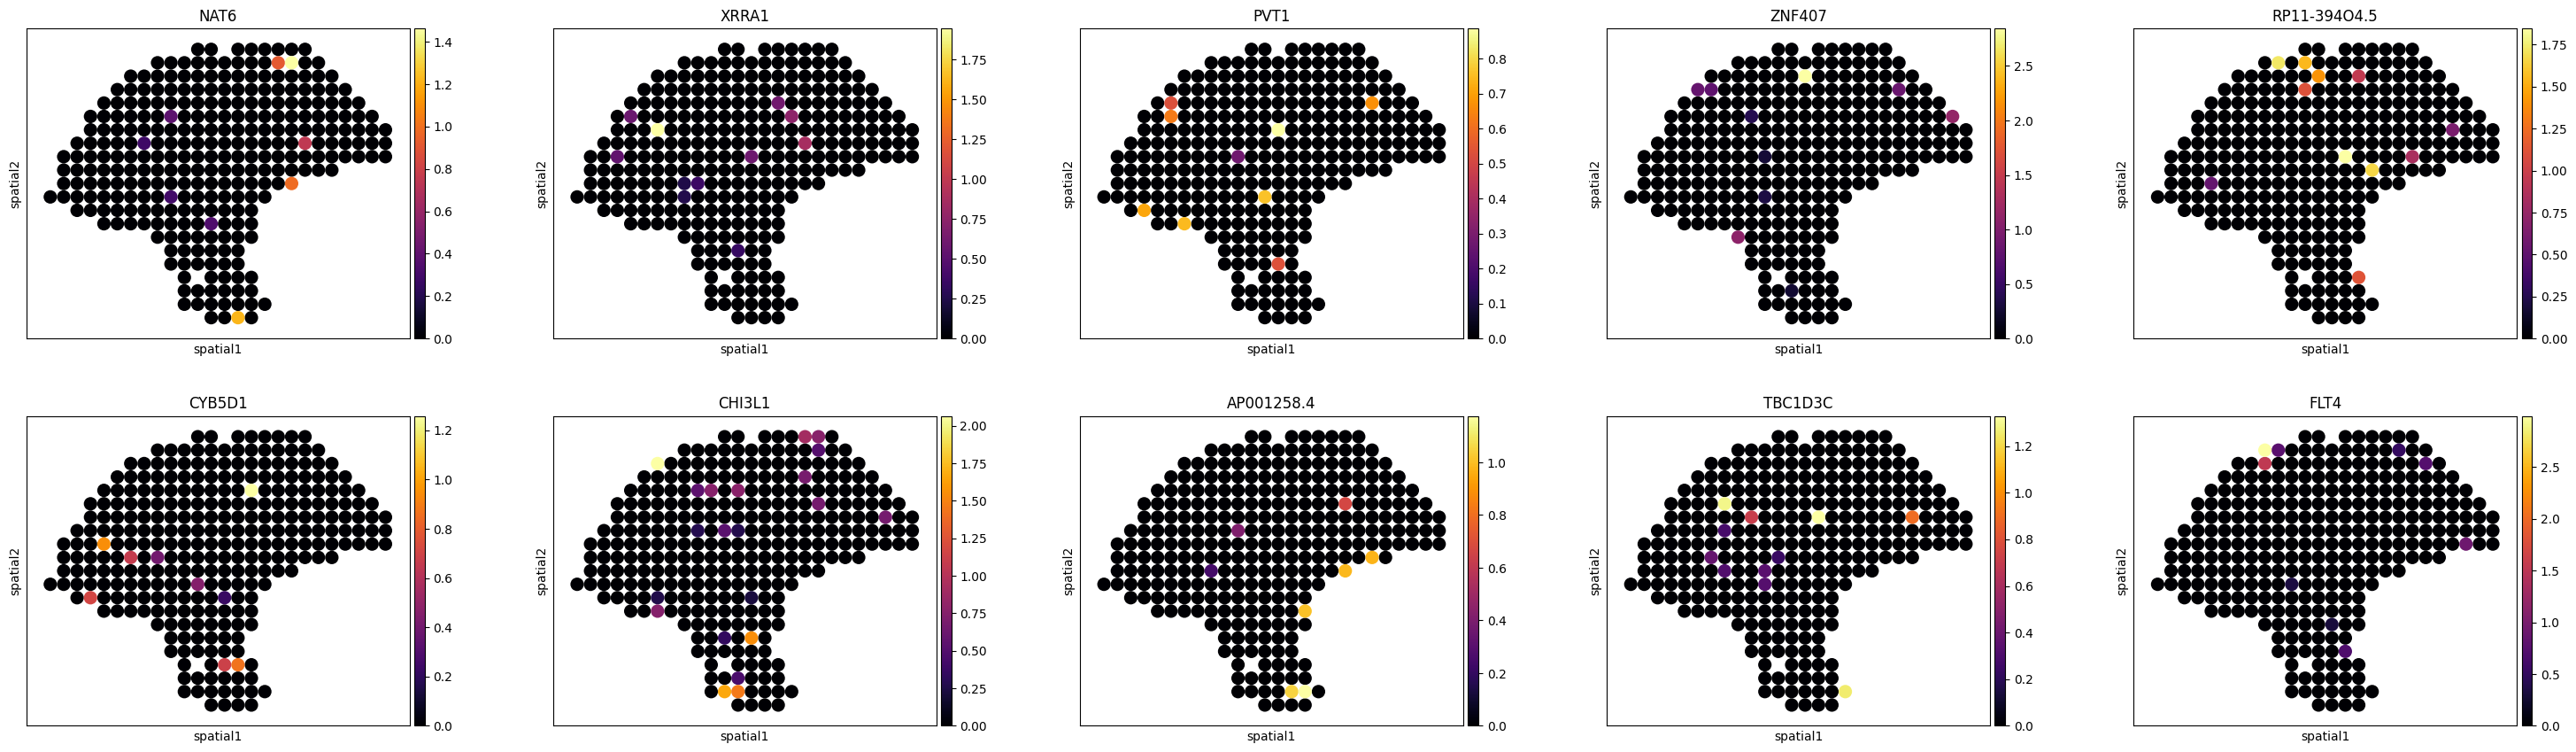

In [46]:
sc.pl.spatial(
    adata,
    color=adata.var["alpha"].sort_values(ascending=False).head(10).index,
    cmap="inferno",
    ncols=5,
    spot_size=1,
    layer="lognorm",
)

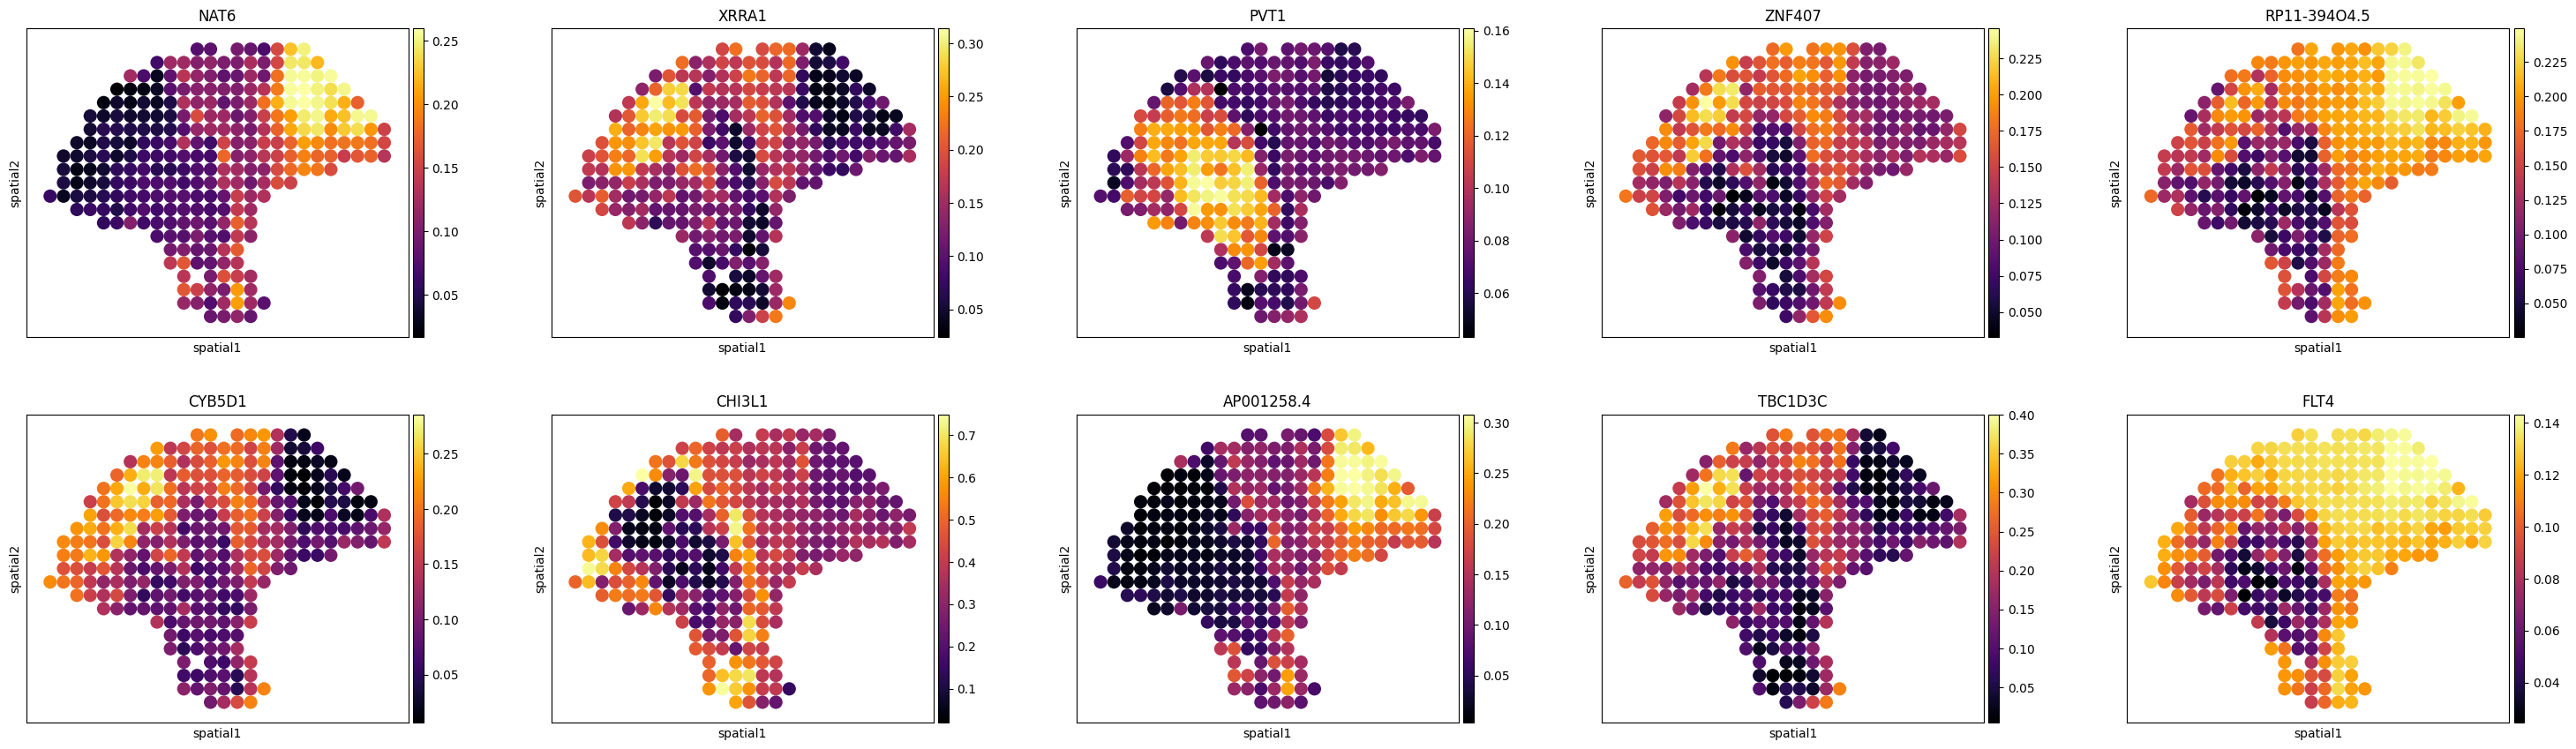

In [47]:
sc.pl.spatial(
    adata,
    color=adata.var["alpha"].sort_values(ascending=False).head(10).index,
    cmap="inferno",
    ncols=5,
    spot_size=1,
    layer="inferred_lognorm",
)

### GO enrichment analysis

In [48]:
q = 0.95
alpha_thr = adata.var["alpha"].quantile(q)

high_alpha_genes = (
    adata.var_names[adata.var["alpha"] >= alpha_thr]
    .astype(str)
    .tolist()
)

background_genes = adata.var_names.astype(str).tolist()

print(f"High-alpha genes: {len(high_alpha_genes)}")
print(f"Background genes: {len(background_genes)}")

High-alpha genes: 548
Background genes: 10942


In [49]:
import gseapy as gp

go_results = gp.enrichr(
    gene_list=high_alpha_genes,
    gene_sets=[
        "GO_Biological_Process_2023",
        "GO_Molecular_Function_2023",
        "GO_Cellular_Component_2023",
    ],
    organism="human",
    background=background_genes,
    outdir=None
)

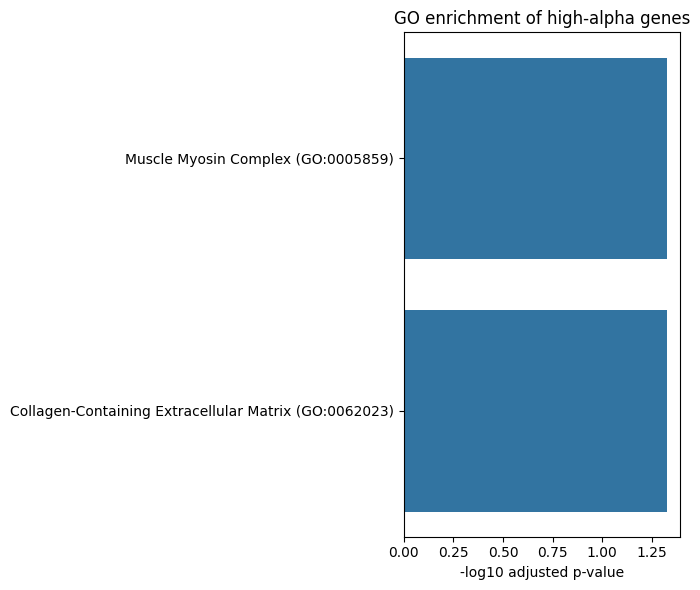

In [50]:
go_df = go_results.results.copy()
sig_go = go_df[go_df["Adjusted P-value"] < 0.05].copy()

top_go = sig_go.head(20).copy()
top_go["minus_log10_fdr"] = -np.log10(top_go["Adjusted P-value"])

plt.figure(figsize=(7, 6))
sns.barplot(
    data=top_go,
    x="minus_log10_fdr",
    y="Term"
)
plt.xlabel("-log10 adjusted p-value")
plt.ylabel("")
plt.title("GO enrichment of high-alpha genes")
plt.tight_layout()
plt.show()

In [51]:
genes = {}

for term in sig_go["Term"].values:
     genes[term] = go_df.loc[
        go_df["Term"] == term,
        "Genes"
    ].iloc[0].split(";")

Muscle Myosin Complex (GO:0005859)


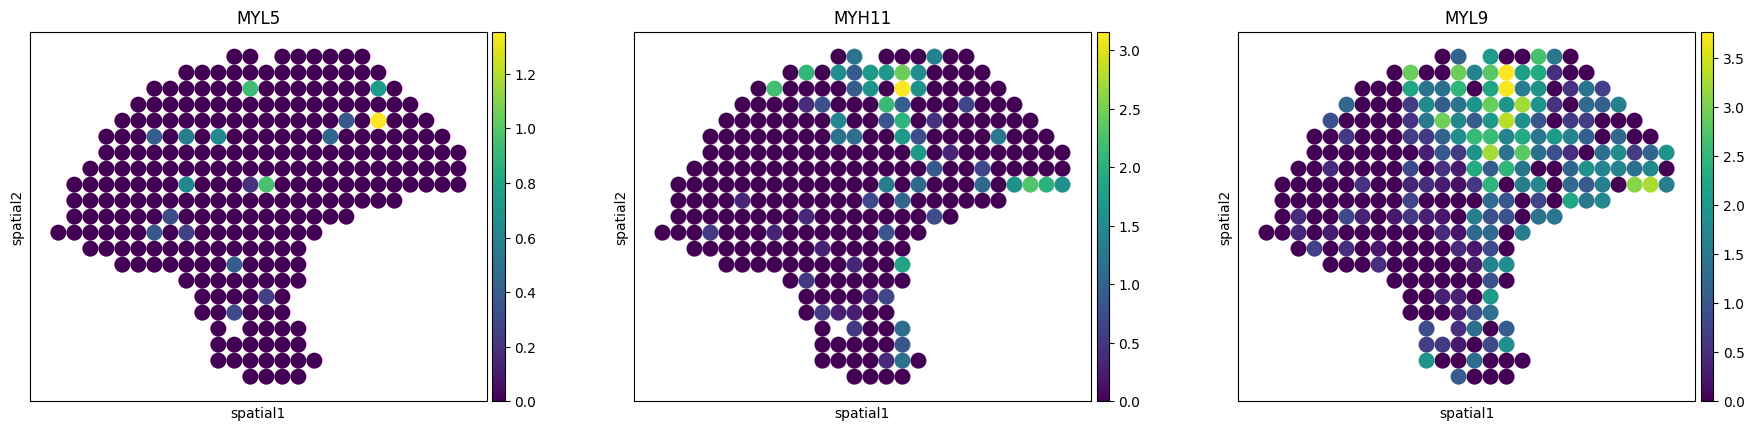

Collagen-Containing Extracellular Matrix (GO:0062023)


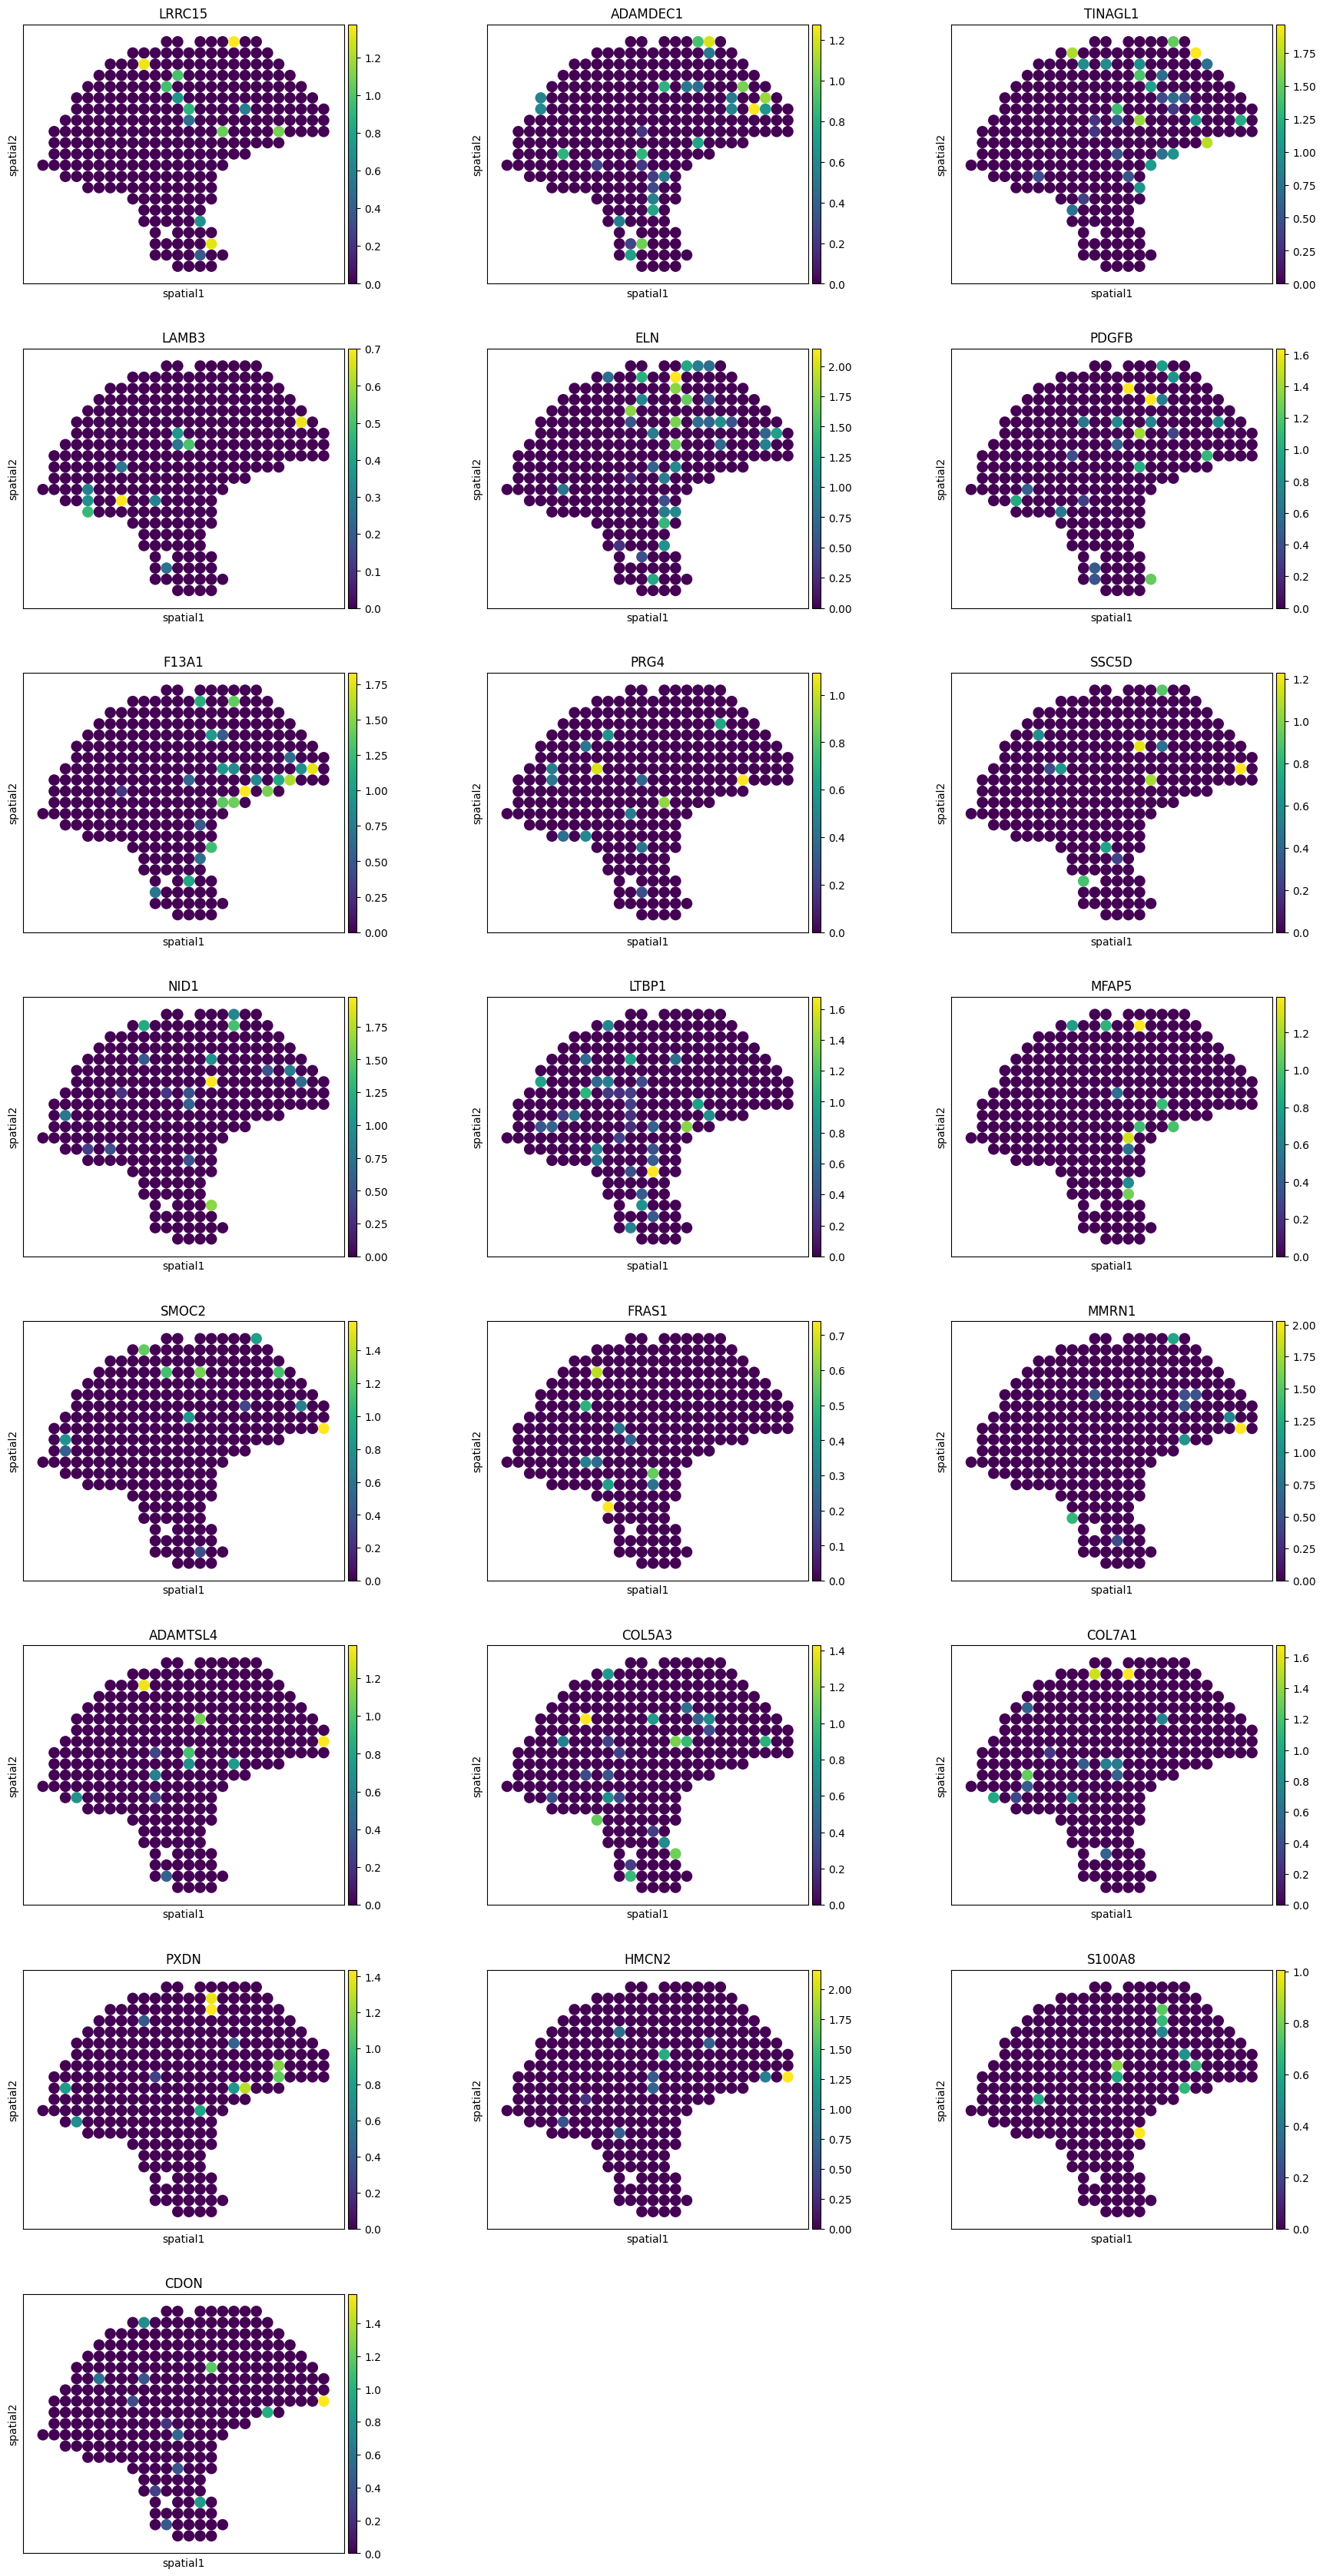

In [52]:
for term, gs in genes.items():

    print(term)

    # keep only genes present in the dataset
    gs = [g for g in gs if g in adata.var_names]

    if len(gs) == 0:
        continue

    fig = sc.pl.spatial(
        adata,
        color=gs,
        cmap="viridis",
        ncols=3,
        spot_size=1,
        return_fig=True,
        layer="lognorm",
    )

The enrichment of the collagen-containing extracellular matrix term is particularly consistent with the biology of metastatic melanoma. Genes such as LRRC15, ELN, LTBP1, MFAP5, NID1, COL5A3, COL7A1, PXDN, and ADAMTSL4 are characteristic of extracellular matrix remodeling, activated fibroblasts, basement membrane organization, and vascular-associated stromal compartments. In stage III melanoma, metastatic invasion into lymph nodes is accompanied by substantial remodeling of the stromal microenvironment through fibroblast activation, collagen deposition, angiogenesis, and extracellular matrix reorganization. These processes are highly localized within the tissue, making them natural candidates for elevated gene-specific dispersion.

The enrichment of the muscle myosin complex initially appears surprising because lymphoid tissue does not contain skeletal muscle. However, the enrichment is driven primarily by MYH11 and MYL9, which are well-established markers of smooth muscle cells, pericytes, vascular-associated cells, and activated myofibroblasts rather than skeletal muscle. These contractile stromal populations are commonly observed around blood vessels and fibrotic regions within metastatic melanoma lesions, indicating that this enrichment likely reflects vascular and stromal remodeling rather than tissue contamination.

Several additional genes reinforce this interpretation. PDGFB is involved in pericyte recruitment and vascular maturation, F13A1 is frequently expressed in activated macrophages and stromal cells, whereas S100A8 and ADAMDEC1 are associated with inflammatory myeloid populations. Together, these genes indicate that the most overdispersed genes participate in processes occurring within spatially restricted stromal and immune niches rather than uniformly across the tissue.

## $\beta_j$

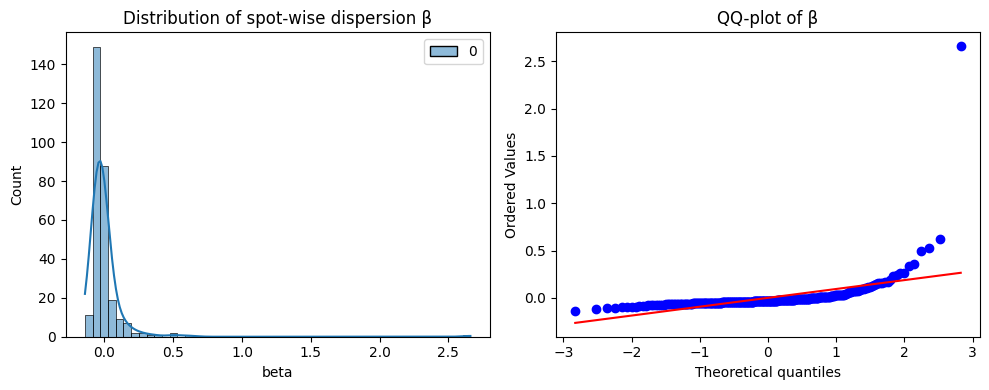

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(beta, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of spot-wise dispersion β")
axes[0].set_xlabel("beta")

probplot(beta.ravel(), dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot of β")

plt.tight_layout()

plt.savefig(f"plots/K{K}_beta_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_beta_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

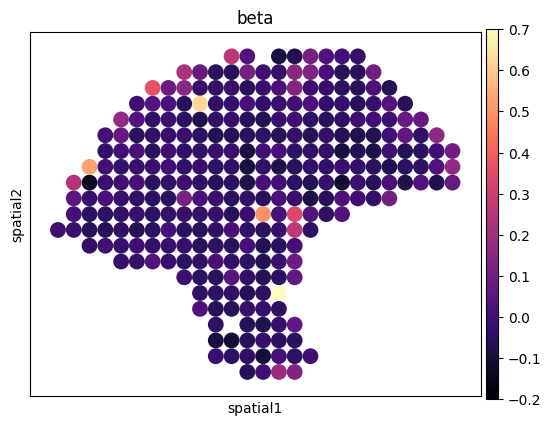

In [54]:
sc.pl.spatial(
    adata,
    color="beta",
    spot_size=1,
    cmap="magma",
    vmin=-0.2,
    vmax=0.7 # Avoid outlier making the plot undistinguisable
)

plt.savefig(f"plots/K{K}_beta_spatial_map.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_beta_spatial_map.pdf", dpi=300, bbox_inches="tight")
plt.close()

### $\beta$ vs library size

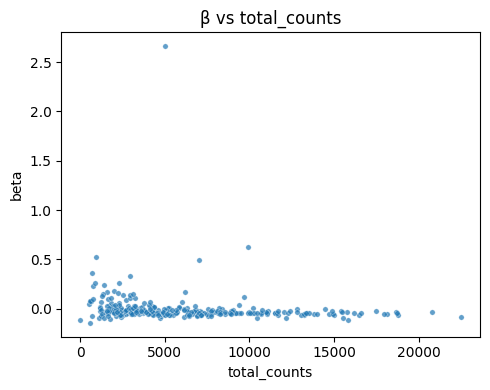

Spearman beta vs total_counts: rho=-0.327, p=1.042e-08


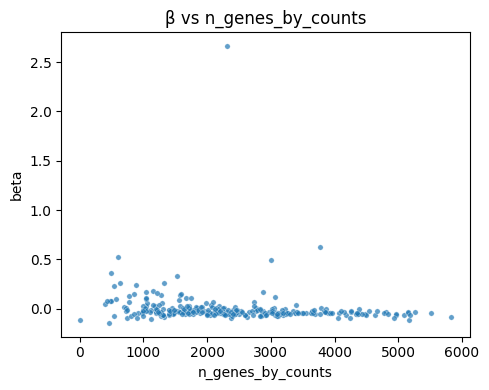

Spearman beta vs n_genes_by_counts: rho=-0.341, p=2.112e-09


In [55]:
# Compute QC metrics if not already present
if "total_counts" not in adata.obs.columns or "n_genes_by_counts" not in adata.obs.columns:
    sc.pp.calculate_qc_metrics(adata, inplace=True, layer="counts")

qc_vars = ["total_counts", "n_genes_by_counts"]

for qc in qc_vars:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(
        data=adata.obs,
        x=qc,
        y="beta",
        s=15,
        alpha=0.7
    )
    plt.xlabel(qc)
    plt.ylabel("beta")
    plt.title(f"β vs {qc}")
    plt.tight_layout()

    plt.savefig(f"plots/K{K}_beta_{qc}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"plots/K{K}_beta_{qc}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    rho, pval = spearmanr(
        adata.obs[qc],
        adata.obs["beta"],
        nan_policy="omit"
    )

    print(f"Spearman beta vs {qc}: rho={rho:.3f}, p={pval:.3e}")

Negative because we are plotting the inverse dispersion. Still, **this low correlation (-0.32) demonstrates that $\beta$ is not merely technical, but captures biology**

### $\beta$ distribution per cell type

/tmp/ipykernel_846876/2682731911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


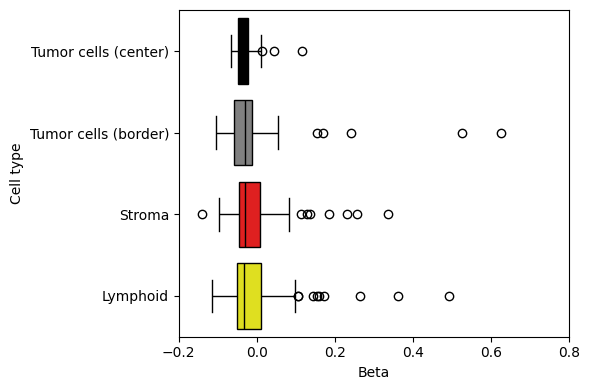

In [56]:
plt.figure(figsize=(6, max(4, 0.3 * len(moran_df))))
ax = sns.boxplot(
    data=adata.obs,
    y="snmf_component",
    x="beta",
    palette=PALETTE
)

ax.set_xlim(-0.2, 0.8)

plt.xlabel("Beta")
plt.ylabel("Cell type")
plt.tight_layout()

plt.savefig(f"plots/K{K}_beta_per_celltype.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_beta_per_celltype.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
for ct in SIGNATURES.keys():
    print(f"Spearman correlation between '{ct}' proportion and beta: {spearmanr(adata.obs[ct], adata.obs['beta']).statistic:.3f}")

Spearman correlation between 'Tumor cells (center)' proportion and beta: -0.172
Spearman correlation between 'Tumor cells (border)' proportion and beta: 0.033
Spearman correlation between 'Stroma' proportion and beta: 0.301
Spearman correlation between 'Lymphoid' proportion and beta: -0.046


In [58]:
adata.obs[ct]

7x15     0.197405
7x16     0.244813
7x17     0.329447
7x18     0.224054
8x13     0.337943
           ...   
27x18    0.263692
27x19    0.174788
27x20    0.550300
27x21    0.811832
27x22    0.925504
Name: Lymphoid, Length: 293, dtype: float64

### $\beta$ enrichment at component boundaries

feature           beta
in_median    -0.032164
out_median   -0.034768
p             0.636864
n_in               210
n_other             83
dtype: object
rho boundary vs beta: 0.09629262361406456
rho prop-gradient vs beta: 0.09938066582002385


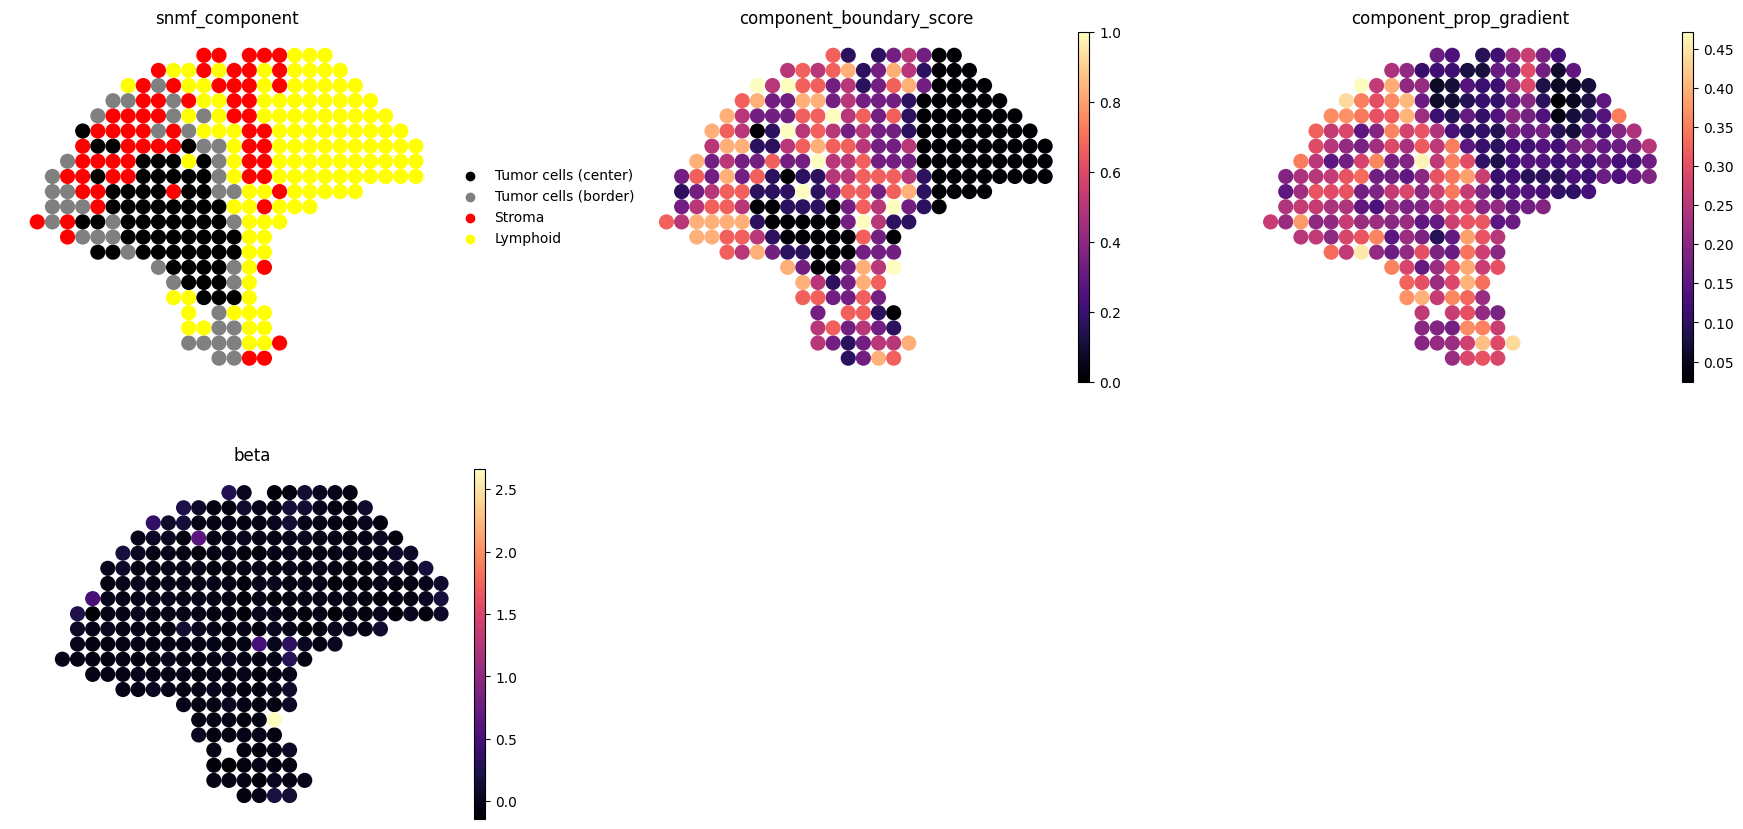

In [59]:
coords = adata.obs[["array_row", "array_col"]].to_numpy() if {"array_row", "array_col"}.issubset(adata.obs.columns) else adata.obsm["spatial"]
tree = cKDTree(coords)
_, nn = tree.query(coords, k=min(7, adata.n_obs))

dominant = adata.obs["snmf_component"].astype(str).to_numpy()
P = snmf_proportions.to_numpy()

boundary_score = []
prop_gradient = []

for i, neigh in enumerate(nn):
    neigh = [j for j in neigh if j != i]
    boundary_score.append(np.mean(dominant[neigh] != dominant[i]))
    prop_gradient.append(np.mean(np.abs(P[neigh] - P[i]).sum(axis=1) / 2))

adata.obs["component_boundary_score"] = boundary_score
adata.obs["component_prop_gradient"] = prop_gradient

boundary_mask = adata.obs["component_boundary_score"] > 0
print(compare_by_mask("beta", boundary_mask))
print("rho boundary vs beta:", spearmanr(adata.obs["component_boundary_score"], adata.obs["beta"]).statistic)
print("rho prop-gradient vs beta:", spearmanr(adata.obs["component_prop_gradient"], adata.obs["beta"]).statistic)

sc.pl.spatial(
    adata,
    color=["snmf_component", "component_boundary_score", "component_prop_gradient", "beta"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=3,
    show=False,
)

plt.show()

# Antigen-presentation heterogeneity in tumor-dominant spots

feature          antigen_expr
in_median            1.103761
out_median           0.927148
U                     10766.0
p                         0.0
effect_size_r        0.559612
n_in                       59
n_other                   234
dtype: object
feature          antigen_beta
in_median            0.280075
out_median            0.29583
U                      4709.0
p                    0.000162
effect_size_r       -0.317833
n_in                       59
n_other                   234
dtype: object
rho tumor score vs antigen beta: -0.09364006484355397


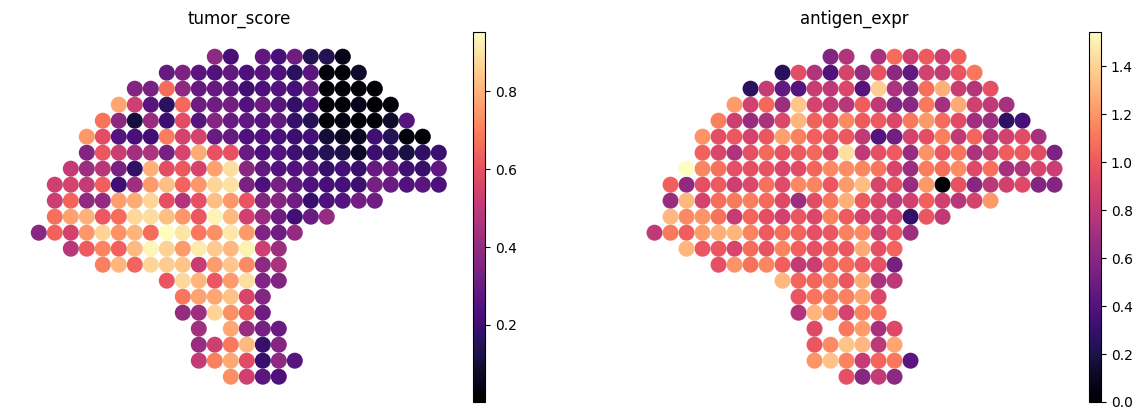

In [91]:
ANTIGEN_GENES = ["B2M", "CALR", "NLRC5", "PSMB9", "PSME1", "PSME3", "RFX5", "HSP90AB1"]

add_expr_score(ANTIGEN_GENES, "antigen_expr", layer="lognorm")
add_phi_score(ANTIGEN_GENES, "antigen_beta")

TUMOR_COMPONENTS = [c for c in SIGNATURES if "Tumor" in c]
adata.obs["tumor_score"] = adata.obs[TUMOR_COMPONENTS].sum(axis=1) if TUMOR_COMPONENTS else 1.0
tumor_mask = adata.obs["tumor_score"] >= adata.obs["tumor_score"].quantile(0.8)

stats_expr = compare_by_mask("antigen_expr", tumor_mask)
stats_beta = compare_by_mask("antigen_beta", tumor_mask)
print(stats_expr)
print(stats_beta)
print("rho tumor score vs antigen beta:", spearmanr(adata.obs["tumor_score"], adata.obs["antigen_beta"]).statistic)

sc.pl.spatial(
    adata,
    color=["tumor_score", "antigen_expr"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=3,
    show=False,
)

plt.savefig(f"plots/K{K}_tumor_score_antigen_presentation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_tumor_score_antigen_presentation.pdf", dpi=300, bbox_inches="tight")
plt.show()

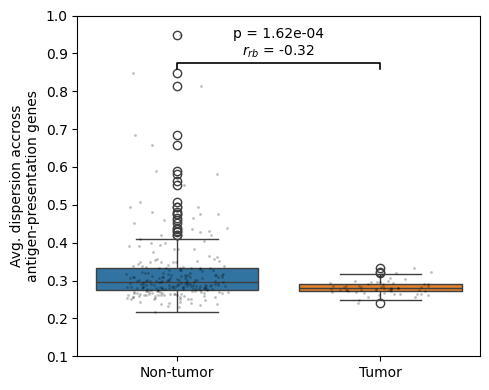

In [99]:
# Label tumor vs non-tumor spots
adata.obs["tumor_group"] = "Non-tumor"
adata.obs.loc[tumor_mask, "tumor_group"] = "Tumor"

# Plot beta values by tumor status
plot_df = adata.obs[["antigen_beta", "tumor_group"]].copy()
plot_df = plot_df.dropna()

plt.figure(figsize=(5, 4))
ax = sns.boxplot(
    data=plot_df,
    x="tumor_group",
    y="antigen_beta",
    hue="tumor_group",
    order=["Non-tumor", "Tumor"],
    # showfliers=False,
)

sns.stripplot(
    data=plot_df,
    x="tumor_group",
    y="antigen_beta",
    order=["Non-tumor", "Tumor"],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25,
)

ax.set_ylim(0.1,1.0)

p_value = stats_beta["p"]
effect_size = stats_beta["effect_size_r"]

x1, x2 = 0, 1
y = 0.86
h = 0.015

ax.plot(
    [x1, x1, x2, x2],
    [y, y + h, y + h, y],
    color="black",
    linewidth=1.2,
)

ax.text(
    (x1 + x2) / 2,
    y + h + 0.008,
    f"p = {p_value:.2e}\n$r_{{rb}}$ = {effect_size:.2f}",
    ha="center",
    va="bottom",
)

plt.xlabel("")
plt.ylabel("Avg. dispersion accross\nantigen-presentation genes")
plt.tight_layout()

plt.savefig(f"plots/K{K}_beta_antigen_tumor_vs_nontumor.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_beta_antigen_tumor_vs_nontumor.pdf", dpi=300, bbox_inches="tight")
plt.show()

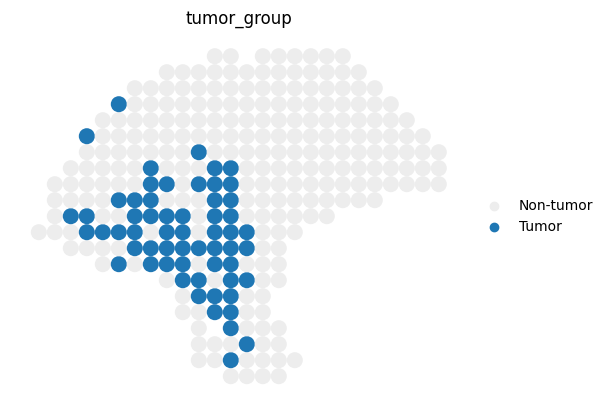

In [62]:
palette = {
    "Tumor": sns.color_palette("tab20")[0],
    "Non-tumor": "#ededed"
}

fig = sc.pl.spatial(
    adata, 
    color="tumor_group",
    spot_size=1,
    frameon=False,
    return_fig=True,
    show=True,
    palette=palette,
)

fig.tight_layout()

fig.savefig(f"plots/K{K}_tumor_region.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_tumor_region.pdf", bbox_inches="tight")

plt.close(fig)


    Test for 'antigen expression'
    Group 1: tumor center (74 spots)
    Group 2: tumor border (74 spots)

    Median 1: 1.0357215404510498
    Median 2: 1.074230670928955

    P-value: 0.4328843492691835


    Test for 'antigen beta'
    Group 1: tumor center (74 spots)
    Group 2: tumor border (74 spots)

    Median 1: 0.2848768843783228
    Median 2: 0.2920041969751842

    P-value: 0.23223761955705946



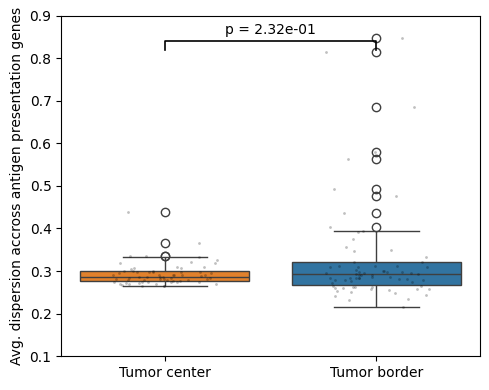

In [87]:
adata.obs["tumor_center_mask"] = adata.obs["Tumor cells (center)"] >= adata.obs["Tumor cells (center)"].quantile(0.75)
adata.obs["tumor_border_mask"] = adata.obs["Tumor cells (border)"] >= adata.obs["Tumor cells (border)"].quantile(0.75)

x = adata.obs.loc[adata.obs["tumor_center_mask"], "antigen_expr"].dropna()
y = adata.obs.loc[adata.obs["tumor_border_mask"], "antigen_expr"].dropna()
p = mannwhitneyu(x, y, alternative="two-sided").pvalue if len(x) and len(y) else np.nan
print(f"""
    Test for 'antigen expression'
    Group 1: tumor center ({len(x)} spots)
    Group 2: tumor border ({len(y)} spots)

    Median 1: {x.median()}
    Median 2: {y.median()}

    P-value: {p}
""")

x = adata.obs.loc[adata.obs["tumor_center_mask"], "antigen_beta"].dropna()
y = adata.obs.loc[adata.obs["tumor_border_mask"], "antigen_beta"].dropna()
p = mannwhitneyu(x, y, alternative="two-sided").pvalue if len(x) and len(y) else np.nan
print(f"""
    Test for 'antigen beta'
    Group 1: tumor center ({len(x)} spots)
    Group 2: tumor border ({len(y)} spots)

    Median 1: {x.median()}
    Median 2: {y.median()}

    P-value: {p}
""")

# Label tumor vs non-tumor spots
adata.obs["tumor_group"] = "Tumor center"
adata.obs.loc[adata.obs["tumor_border_mask"], "tumor_group"] = "Tumor border"

# Plot beta values by tumor status
tumor_mask = adata.obs["tumor_center_mask"] | adata.obs["tumor_border_mask"]
plot_df = adata.obs.loc[tumor_mask, ["antigen_beta", "tumor_group"]].copy()
plot_df = plot_df.dropna()

plt.figure(figsize=(5, 4))
ax = sns.boxplot(
    data=plot_df,
    x="tumor_group",
    y="antigen_beta",
    hue="tumor_group",
    order=["Tumor center", "Tumor border"],
)

sns.stripplot(
    data=plot_df,
    x="tumor_group",
    y="antigen_beta",
    order=["Tumor center", "Tumor border"],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25,
)

ax.set_ylim(0.1,0.9)

x1, x2 = 0, 1
y = 0.76
h = 0.015

ax.plot(
    [x1, x1, x2, x2],
    [y, y + h, y + h, y],
    color="black",
    linewidth=1.2,
)

ax.text(
    (x1 + x2) / 2,
    y + h + 0.01,
    f"p = {p:.2e}",
    ha="center",
    va="bottom",
)

plt.xlabel("")
plt.ylabel("Avg. dispersion accross\nantigen presentation genes")
plt.tight_layout()

plt.savefig(f"plots/K{K}_beta_antigen_tumor_center_vs_border.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_beta_antigen_tumor_center_vs_border.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Transition area

In [64]:
TRANSITION_AREA_EXPRESSED_GENES = ["FTL","B2M","APOE","HLA-A","HLA-B","HLA-C"]

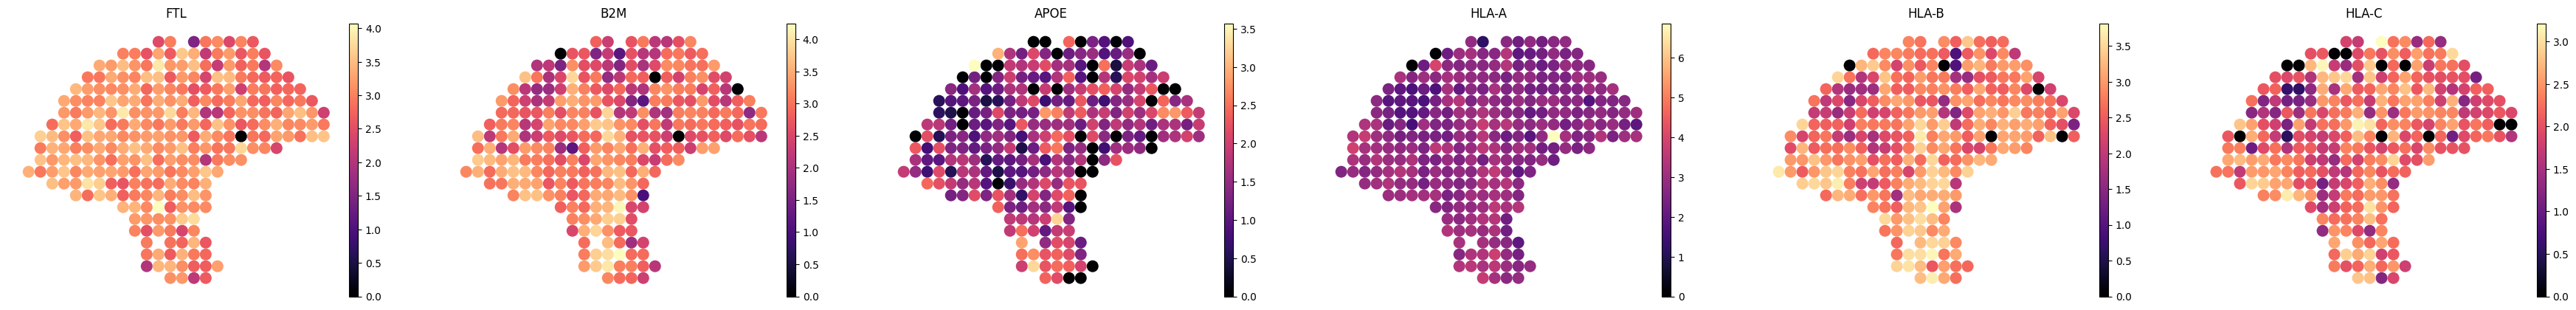

/tmp/ipykernel_846876/3570750304.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [65]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True,
    layer="lognorm",
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_V_transition_genes_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_V_transition_genes_spatial.pdf", bbox_inches="tight")

plt.close(fig)

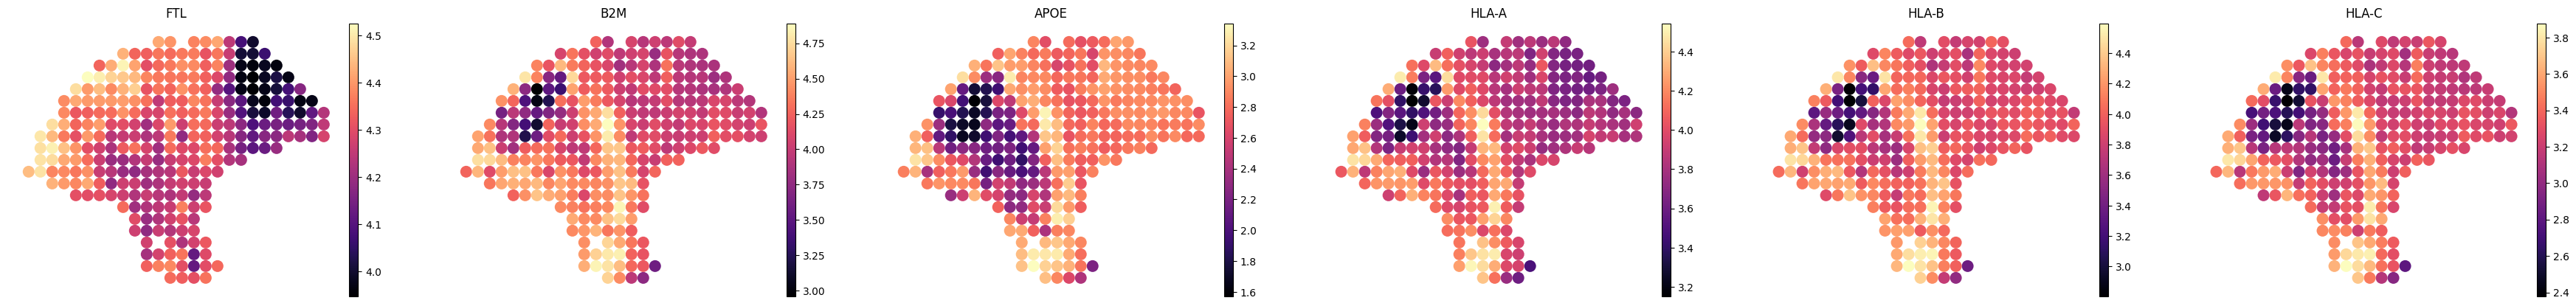

/tmp/ipykernel_846876/3210567711.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [66]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_WHS_transition_genes_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_WHS_transition_genes_spatial.pdf", bbox_inches="tight")

plt.close(fig)

### Observed $V$

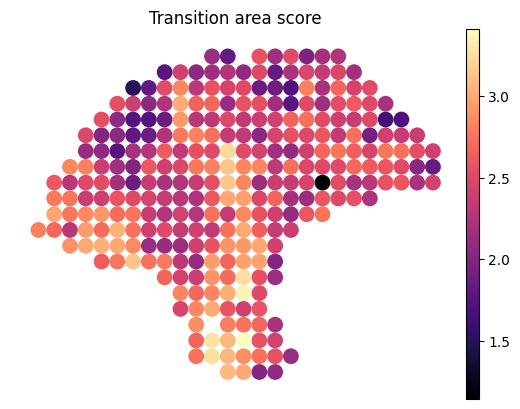

In [67]:
add_expr_score(TRANSITION_AREA_EXPRESSED_GENES, "transition_area_score_V", layer="lognorm")

# Plot single spatial score
fig = sc.pl.spatial(
    adata,
    color="transition_area_score_V",
    spot_size=1,
    frameon=False,
    cmap="magma",
    title="Transition area score",
    return_fig=True,
    show=True
)

# Optional: resize figure for better visibility
fig.set_size_inches(6, 6)

fig.savefig(f"plots/K{K}_V_transition_score.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_V_transition_score.pdf", bbox_inches="tight")
fig.tight_layout()

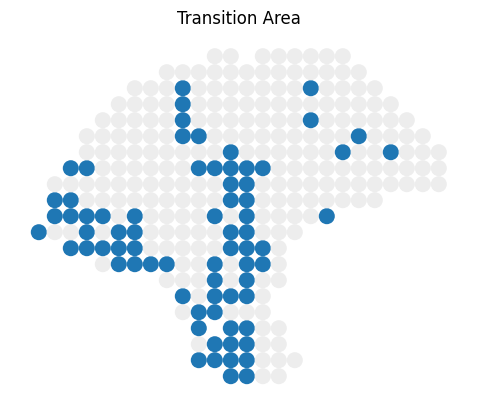

In [68]:
adata.obs["is_in_transition_area_V"] = np.where(
    adata.obs["transition_area_score_V"] > adata.obs["transition_area_score_V"].quantile(0.75),
    "in_transition",
    "out_of_transition"  # use a string instead of None
)

# Optional: make "out_of_transition" white
palette = {
    "in_transition": sns.color_palette("tab20")[0],
    "out_of_transition": "#ededed"
}

fig = sc.pl.spatial(
    adata,
    color="is_in_transition_area_V",
    spot_size=1,
    frameon=False,
    palette=palette,
    legend_loc="none",
    title="Transition Area",
    return_fig=True,
    show=True
)

# Optional: resize
fig.set_size_inches(6, 6)

fig.savefig(f"plots/K{K}_V_transition_mask.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_V_transition_mask.pdf", bbox_inches="tight")
fig.tight_layout()

### Inferred $\hat{V} = WHS$

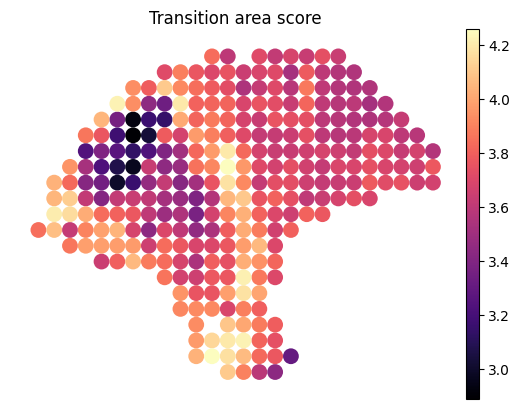

In [69]:
add_expr_score(TRANSITION_AREA_EXPRESSED_GENES, "transition_area_score_WHS")

# Plot single spatial score
fig = sc.pl.spatial(
    adata,
    color="transition_area_score_WHS",
    spot_size=1,
    frameon=False,
    cmap="magma",
    title="Transition area score",
    return_fig=True,
    show=True
)

# Optional: resize figure for better visibility
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save both PNG and PDF
fig.savefig(f"plots/K{K}_WHS_transition_score.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_WHS_transition_score.pdf", bbox_inches="tight")
plt.close(fig)

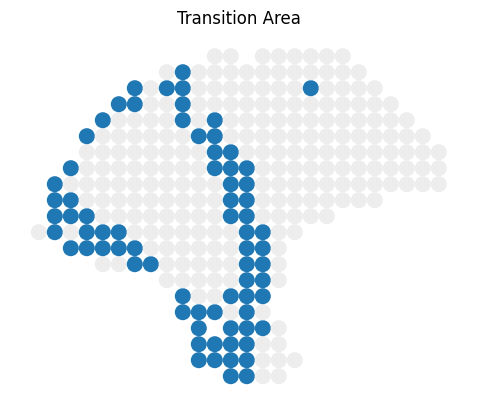

In [70]:
adata.obs["is_in_transition_area_WHS"] = np.where(
    adata.obs["transition_area_score_WHS"] > adata.obs["transition_area_score_WHS"].quantile(0.75),
    "in_transition",
    "out_of_transition"  # use a string instead of None
)

# Optional: make "out_of_transition" white
palette = {
    "in_transition": sns.color_palette("tab20")[0],
    "out_of_transition": "#ededed"
}

fig = sc.pl.spatial(
    adata,
    color="is_in_transition_area_WHS",
    spot_size=1,
    frameon=False,
    palette=palette,
    legend_loc="none",
    title="Transition Area",
    return_fig=True,
    show=True
)

# Optional: resize
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save figure
fig.savefig(f"plots/K{K}_WHS_transition_mask.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_WHS_transition_mask.pdf", bbox_inches="tight")

plt.close(fig)

In [71]:
for component in SIGNATURES.keys():
    rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area_WHS"] == "in_transition",component].values, adata.obs.loc[adata.obs["is_in_transition_area_WHS"] == "in_transition","transition_area_score_WHS"].values)
    print(f"Spearman correlation between '{component}' component and transition area score: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between 'Tumor cells (center)' component and transition area score: -0.0116 (pval 0.9224)
Spearman correlation between 'Tumor cells (border)' component and transition area score: 0.8378 (pval 0.0000)
Spearman correlation between 'Stroma' component and transition area score: -0.3379 (pval 0.0035)
Spearman correlation between 'Lymphoid' component and transition area score: -0.2007 (pval 0.0887)


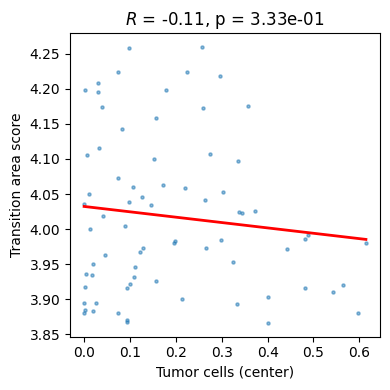

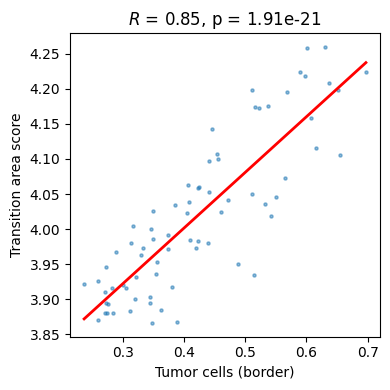

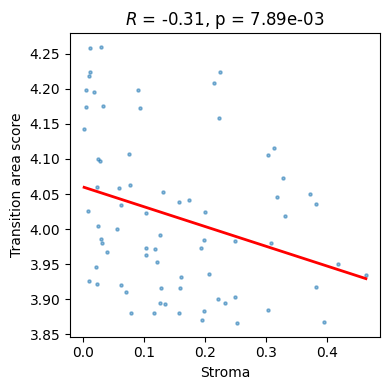

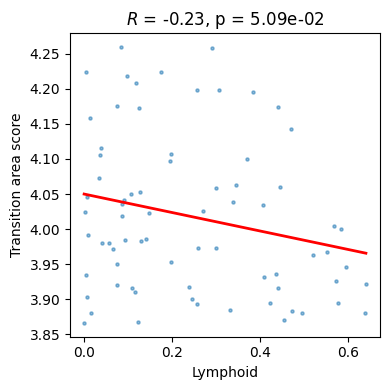

In [72]:
from scipy.stats import linregress

mask = adata.obs["is_in_transition_area_WHS"] == "in_transition"

for component in SIGNATURES.keys():
    x = adata.obs.loc[mask, component].to_numpy()
    y = adata.obs.loc[mask, "transition_area_score_WHS"].to_numpy()

    # Remove missing or infinite values
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 or np.all(x == x[0]):
        print(f"Skipping {component}: insufficient variation")
        continue

    slope, intercept, r, p, _ = linregress(x, y)

    fig, ax = plt.subplots(figsize=(4, 4))

    ax.scatter(x, y, s=5, alpha=0.5)

    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, slope * xx + intercept, color="red", lw=2)

    ax.set_xlabel(component)
    ax.set_ylabel("Transition area score")
    ax.set_title(f"$R$ = {r:.2f}, p = {p:.2e}")

    fig.tight_layout()

    safe_component = component.replace(" ", "_").replace("/", "_")

    fig.savefig(
        f"plots/K{K}_{safe_component}_corr.pdf",
        bbox_inches="tight"
    )
    fig.savefig(
        f"plots/K{K}_{safe_component}_corr.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

In [73]:
from scipy.stats import entropy

adata.obs["entropy"] = entropy(snmf_proportions, axis=1)
rho, pval = spearmanr(adata.obs["entropy"].values, adata.obs["transition_area_score_WHS"].values)
print(f"Spearman correlation between proportions entropy and transition area: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between proportions entropy and transition area: 0.4370 (pval 0.0000)


# Residual analysis

In [74]:
X = adata.layers["counts"]
Mu = adata.layers["inferred_counts"]

eps = 1e-10

Mu = np.maximum(Mu, eps)
Phi = np.maximum(phi, eps)

Var = Mu + Phi * Mu**2

pearson_residuals = (X - Mu) / np.sqrt(Var).to_numpy()

adata.layers["residual"] = pearson_residuals

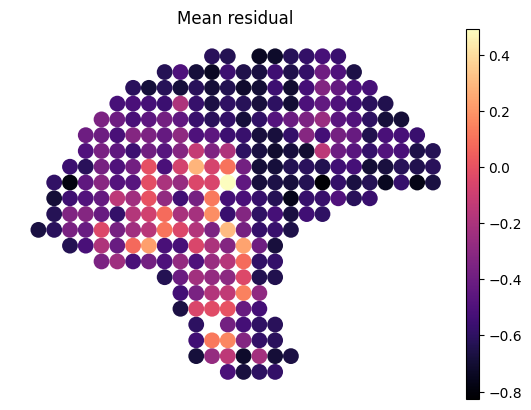

In [75]:
adata.obs["mean_residual"] = np.mean(pearson_residuals, axis=1)
sc.pl.spatial(
    adata,
    color="mean_residual",
    spot_size=1,
    frameon=False,
    cmap="magma",
    title="Mean residual",
)

plt.savefig(f"plots/K{K}_residuals.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_residuals.pdf", bbox_inches="tight")
plt.close()

The model presents a weaker fit in the tumor (center) region, where the $\beta$ is lower (dispersion is higher).

# Unannotated stroma region

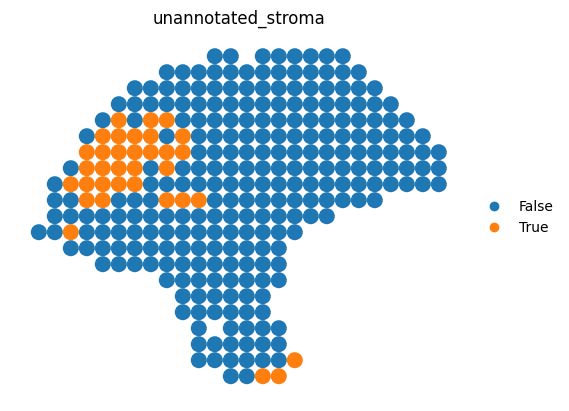

In [76]:
adata.obs["unannotated_stroma"] = (
    (adata.obs["Stroma"] >= adata.obs["Stroma"].quantile(0.75)) &
    (adata.obs["Tumor cells (center)"] >= adata.obs["Tumor cells (center)"].quantile(0.5))
)

sc.pl.spatial(
    adata,
    color="unannotated_stroma",
    spot_size=1,
    frameon=False,
    title=None
)

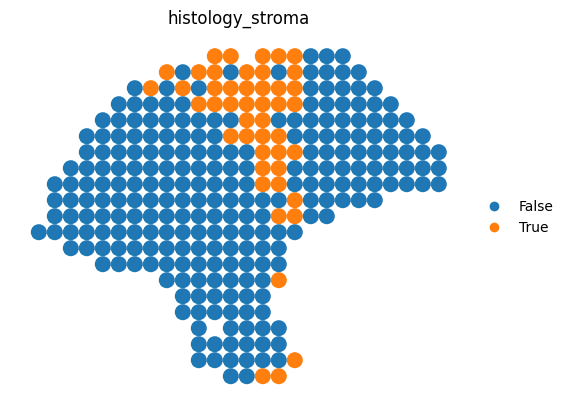

In [77]:
adata.obs["histology_stroma"] = (
    (adata.obs["Stroma"] >= adata.obs["Stroma"].quantile(0.7)) &
    (adata.obs["Lymphoid"] >= adata.obs["Lymphoid"].quantile(0.4))
)

sc.pl.spatial(
    adata,
    color="histology_stroma",
    spot_size=1,
    frameon=False,
    title=None
)

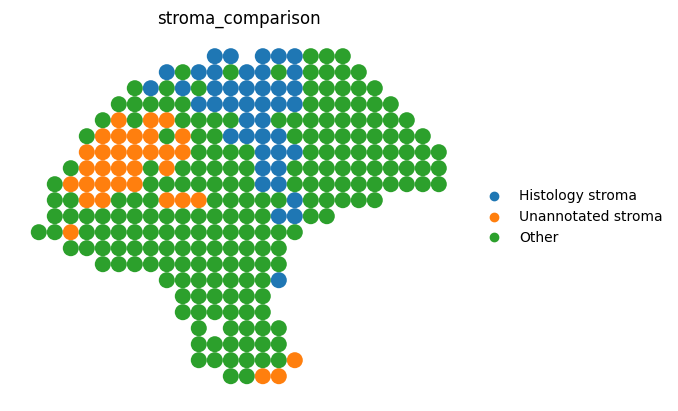

In [78]:
adata.obs["stroma_comparison"] = "Other"

adata.obs.loc[
    adata.obs["histology_stroma"],
    "stroma_comparison"
] = "Histology stroma"

adata.obs.loc[
    adata.obs["unannotated_stroma"],
    "stroma_comparison"
] = "Unannotated stroma"

adata.obs["stroma_comparison"] = pd.Categorical(
    adata.obs["stroma_comparison"],
    categories=[
        "Histology stroma",
        "Unannotated stroma",
        "Other"
    ]
)

sc.pl.spatial(
    adata,
    color="stroma_comparison",
    spot_size=1,
    frameon=False,
    title=None
)

plt.savefig(f"plots/K{K}_stroma_mask.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_stroma_mask.pdf", bbox_inches="tight")
plt.close()

In [79]:
X = adata.layers["lognorm"]

if sparse.issparse(X):
    X = X.toarray()

hist = X[adata.obs["histology_stroma"]]
unann = X[adata.obs["unannotated_stroma"]]

hist_mean = hist.mean(axis=0)
unann_mean = unann.mean(axis=0)

r, _ = pearsonr(hist_mean, unann_mean)

print(f"Pearson correlation between mismatched and histology stroma = {r:.3f}")

adata.obs["melanoma"] = (
    adata.obs["snmf_component"] == "Tumor cells (center)"
)

melanoma = X[adata.obs["melanoma"]]
melanoma_mean = melanoma.mean(axis=0)

r, _ = pearsonr(hist_mean, melanoma_mean)

print(f"Pearson correlation between mismatched stroma and melanoma = {r:.3f}")

Pearson correlation between mismatched and histology stroma = 0.934
Pearson correlation between mismatched stroma and melanoma = 0.919


In [80]:
adata_stroma = adata[
    adata.obs["stroma_comparison"].isin(
        ["Histology stroma", "Unannotated stroma"]
    )
].copy()

adata_stroma.obs["stroma_comparison"] = (
    adata_stroma.obs["stroma_comparison"]
    .cat.remove_unused_categories()
)

sc.tl.rank_genes_groups(
    adata_stroma,
    groupby="stroma_comparison",
    groups=["Unannotated stroma"],
    reference="Histology stroma",
    method="wilcoxon",
    layer="lognorm",
    use_raw=False,
    pts=True,
    key_added="unannotated_vs_histology_stroma"
)

In [81]:
de = sc.get.rank_genes_groups_df(
    adata_stroma,
    group="Unannotated stroma",
    key="unannotated_vs_histology_stroma"
)

de = de.sort_values("pvals_adj")
de.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
10941,ACTB,-6.226706,-0.935552,4.763453e-10,0.000005,1.000000
10940,IGLL5,-6.083091,-2.821470,1.178872e-09,0.000006,0.705882
10939,CD74,-5.780476,-2.463121,7.448984e-09,0.000027,0.735294
0,METTL9,5.621474,3.410137,1.893352e-08,0.000052,0.911765
1,SPP1,5.559925,1.009448,2.698908e-08,0.000059,1.000000
10938,COL1A1,-5.488118,-3.609210,4.062393e-08,0.000074,0.294118
2,NEAT1,5.354762,1.494467,8.566931e-08,0.000134,1.000000
3,EIF4A2,5.282954,2.720335,1.271170e-07,0.000174,0.941176
4,ATP1A1,5.241922,1.223656,1.589127e-07,0.000193,1.000000
5,TPT1,5.190631,0.711941,2.095827e-07,0.000229,1.000000


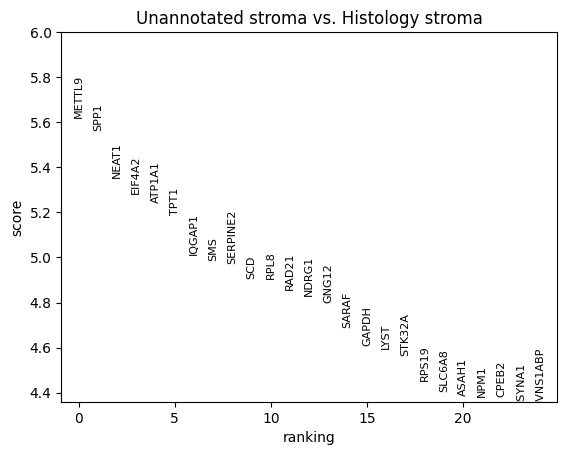

In [82]:
sc.pl.rank_genes_groups(
    adata_stroma,
    key="unannotated_vs_histology_stroma",
    n_genes=25,
    sharey=False
)

plt.savefig(f"plots/K{K}_mismatched_vs_hist_stroma_de_genes.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_mismatched_vs_hist_stroma_de_genes.pdf", bbox_inches="tight")
plt.close()

In [83]:
de = de.drop_duplicates(subset="names")

# Ranking for preranked GSEA
ranking = (
    de[["names", "scores"]]
    .dropna()
    .sort_values("scores", ascending=False)
)

pre_res = gp.prerank(
    rnk=ranking,
    gene_sets="MSigDB_Hallmark_2020",
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    seed=42,
    outdir=None
)

results = pre_res.res2d
results = results.sort_values("FDR q-val")
results.head(20)

2026-09-08 12:39:27,387 [WARNING] Duplicated values found in preranked stats: 91.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Myc Targets V1,0.598397,1.707060,0.000000,0.000824,0.001,111/192,23.32%,NPM1;LDHA;RSL1D1;C1QBP;PCNA;RPS3;DHX15;HSPE1;C...
1,prerank,Protein Secretion,0.584682,1.611617,0.000000,0.003710,0.009,59/91,31.25%,ATP1A1;GNAS;RPS6KA3;STX7;STAM;LAMP2;TMX1;COPB2...
2,prerank,Pancreas Beta Cells,0.690812,1.522431,0.017467,0.011266,0.040,6/12,14.22%,AKT3;STXBP1;SPCS1;MAFB;SRP9;SRP14
3,prerank,Androgen Response,0.545640,1.500432,0.001000,0.012983,0.058,40/82,28.44%,SMS;SCD;NDRG1;RPS6KA3;SLC38A2;IQGAP2;AKT1;PA2G...
4,prerank,Oxidative Phosphorylation,0.521660,1.480497,0.000000,0.013519,0.074,88/176,27.43%,LDHA;SLC25A6;ECH1;VDAC1;ATP6V1C1;NNT;ATP6V1G1;...
6,prerank,Myc Targets V2,0.521597,1.393213,0.013092,0.040805,0.249,20/54,19.30%,NPM1;HSPE1;HSPD1;PA2G4;SRM;PES1;GNL3;PHB;DDX18...
7,prerank,Wnt-beta Catenin Signaling,0.547965,1.373730,0.031697,0.044985,0.304,13/30,17.76%,CTNNB1;MYC;CUL1;HDAC5;NCOR2;JAG1;NUMB;GNAI1;RB...
8,prerank,mTORC1 Signaling,0.479760,1.360313,0.000000,0.047399,0.356,76/184,25.41%,SCD;GAPDH;LDHA;HSPE1;HSP90B1;HSPD1;SLC2A3;ATP2...
9,prerank,Unfolded Protein Response,0.481138,1.342533,0.005020,0.054040,0.436,50/103,32.58%,EIF4A2;NPM1;KHSRP;HSP90B1;YWHAZ;VEGFA;ARFGAP1;...
12,prerank,heme Metabolism,0.456949,1.276921,0.004000,0.098646,0.750,58/140,29.19%,SLC6A8;TYR;GYPC;RNF19A;NEK7;NNT;TFRC;LAMP2;LPI...


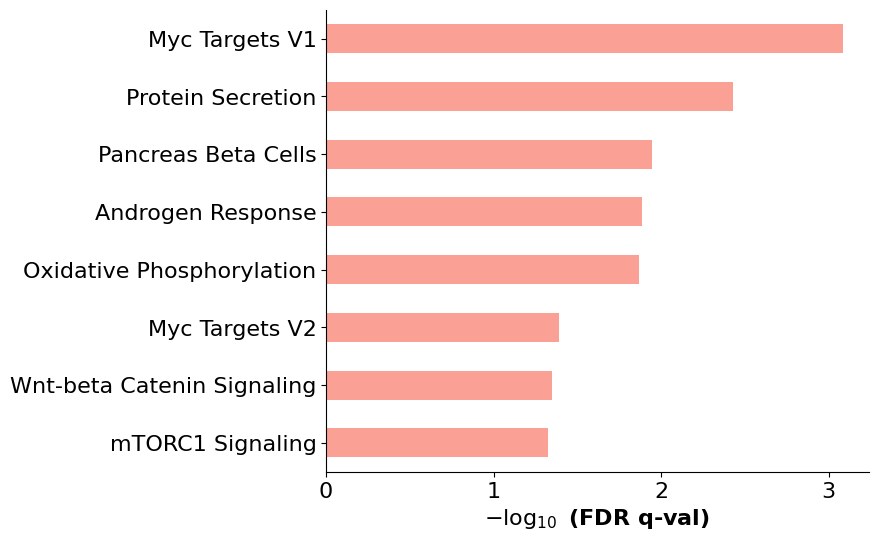

In [84]:
gp.barplot(
    results,
    column="FDR q-val",
    top_term=20,
    figsize=(7,6)
)

plt.savefig(f"plots/K{K}_mismatched_vs_hist_stroma_gsea_barplot.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_mismatched_vs_hist_stroma_gsea_barplot.pdf", bbox_inches="tight")
plt.show()

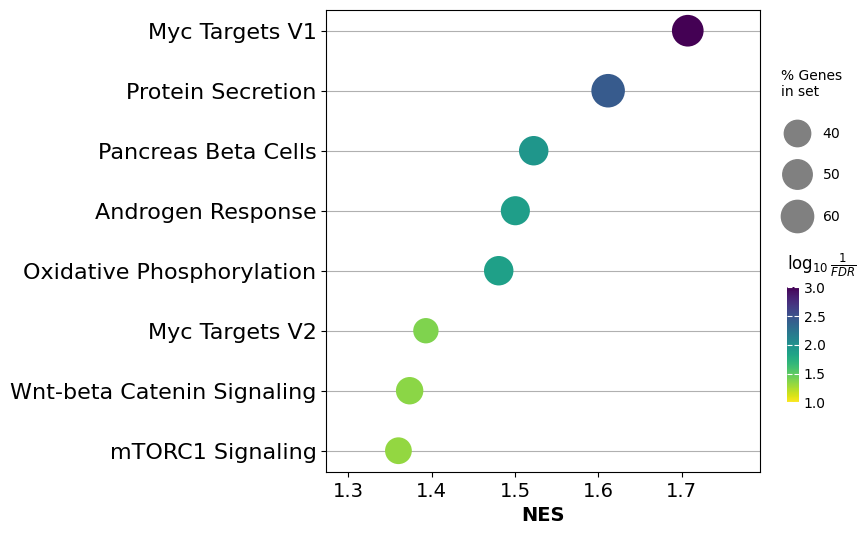

In [85]:
gp.dotplot(
    results,
    column="FDR q-val",
    top_term=20,
    figsize=(7,6)
)

plt.savefig(f"plots/K{K}_mismatched_vs_hist_stroma_gsea_dotplot.png", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/K{K}_mismatched_vs_hist_stroma_gsea_dotplot.pdf", bbox_inches="tight")
plt.show()